In [ ]:
#!/usr/bin/env python3
"""
CW Module Explorer — COMPUTE BLOCK (Multi-Family / Multi-Rep)
==============================================================
Discovers all run families under RUNS_ANALYSIS_ROOT, then for each family:
  - Locates the shared states file:  <family>/states/<family>_rollouts.npy
  - Discovers every rep folder:      <family>/PostVal_*/checkpoints/accepted/
  - Runs compute_cache independently for each rep, saving the cache to:
                                     <rep>/checkpoints/accepted/_module_explorer_cache/

Directory contract (hard-coded, not discovered dynamically):
  RUNS_ANALYSIS_ROOT/
    <family>/                           ← immediate subfolder = one family
      states/
        <family>_rollouts.npy           ← states file for ALL reps in this family
      <rep_folder>/                     ← one or more rep folders (PostVal_…)
        checkpoints/
          accepted/                     ← checkpoint root
            <ckpt_dirs>/
              actor.index
            _module_explorer_cache/     ← written here by this script

Cache structure is identical to the original single-run script:
  phase_summary.csv
  plot_cache_index.csv
  plot_cache_npz/

Outputs a top-level manifest at:
  RUNS_ANALYSIS_ROOT/_compute_manifest.csv
"""

from __future__ import annotations

import os
import gc
import re
import glob
import shutil
import random
import traceback
from pathlib import Path

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from scipy.optimize import linear_sum_assignment
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import reverse_cuthill_mckee, connected_components

# ============================================================
# ========================= CONFIG ===========================
# ============================================================

# Root that contains all family subfolders (triA, triC, quadA, pentaA, …)
RUNS_ANALYSIS_ROOT = "/Users/adi/Desktop/Runs_Analysis"

# ----- MULTI-RUN CONTROL -----
RECOMPUTE_OVERWRITE    = True
CONTINUE_ON_RUN_ERROR  = True

# ----- ACTOR ARCHITECTURE -----
HIDDEN_SIZES  = [256, 256, 256, 256]
ACTIVATION    = "lrelu"
LAYER_INDICES = [0, 1, 2, 3]

# ----- ANALYSIS PARAMS -----
SEED              = 42
EPS               = 1e-8
MIN_STD           = 1e-5
TAU               = 0.90
BD_MIN_BLOCK_SIZE = 1

MAX_INPUT_STATES  = None   # None = use all states; or int to subsample

# ----- CACHE CONTROL -----
PLOT_CACHE_N_CYCLES    = 10
TOPK_CLUSTERS_SUMMARY  = 2   # rank1=self, rank2=task

# ============================================================
# ========================= SETUP ============================
# ============================================================

def _seed_everything(seed: int):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

_seed_everything(SEED)

# ============================================================
# =============== CONTINUAL-WORLD ACTOR REBUILD ==============
# ============================================================

class CW_MlpActor(tf.keras.Model):
    def __init__(self, obs_dim, act_dim, hidden_sizes, activation="lrelu", name="cw_mlp_actor"):
        super().__init__(name=name)
        self.obs_dim         = int(obs_dim)
        self.act_dim         = int(act_dim)
        self.hidden_sizes    = list(hidden_sizes)
        self.activation_name = activation

        self.hidden_layers = []
        for i, h in enumerate(self.hidden_sizes):
            self.hidden_layers.append(
                tf.keras.layers.Dense(h, activation=None, use_bias=True, name=f"dense_{i}")
            )
        self.mu_layer      = tf.keras.layers.Dense(self.act_dim, activation=None, use_bias=True, name="mu")
        self.log_std_layer = tf.keras.layers.Dense(self.act_dim, activation=None, use_bias=True, name="log_std")

    def _act(self, x):
        if   self.activation_name == "relu":   return tf.nn.relu(x)
        elif self.activation_name == "tanh":   return tf.nn.tanh(x)
        elif self.activation_name == "elu":    return tf.nn.elu(x)
        elif self.activation_name == "lrelu":  return tf.nn.leaky_relu(x, alpha=0.2)
        else: raise ValueError(f"Unsupported activation: {self.activation_name}")

    def trunk_hidden_numpy(self, x_np):
        h = tf.convert_to_tensor(x_np, dtype=tf.float32)
        outs = []
        for layer in self.hidden_layers:
            h = layer(h)
            h = self._act(h)
            outs.append(h.numpy().astype(np.float32, copy=False))
        return outs

    def call(self, obs):
        h = obs
        for layer in self.hidden_layers:
            h = layer(h)
            h = self._act(h)
        mu      = self.mu_layer(h)
        log_std = self.log_std_layer(h)
        log_std = tf.clip_by_value(log_std, -20.0, 2.0)
        std     = tf.exp(log_std)
        noise   = tf.random.normal(tf.shape(mu))
        pi      = mu + noise * std
        logp_pi = tf.zeros((tf.shape(obs)[0],), dtype=tf.float32)
        return mu, log_std, pi, logp_pi


def _infer_obs_act_dims_from_checkpoint(actor_prefix):
    vars_meta = tf.train.list_variables(actor_prefix)
    kernels   = [(n, s) for n, s in vars_meta if len(s) == 2]
    if not kernels:
        raise RuntimeError(f"No 2D tensors in {actor_prefix}")

    first_hidden     = HIDDEN_SIZES[0]
    first_candidates = [(n, s) for n, s in kernels if s[1] == first_hidden]
    if not first_candidates:
        raise RuntimeError(f"No kernel with output dim {first_hidden}")
    _, first_shape = sorted(first_candidates, key=lambda t: t[1][0])[0]
    obs_dim = int(first_shape[0])

    last_hidden    = HIDDEN_SIZES[-1]
    out_candidates = [(n, s) for n, s in kernels if s[0] == last_hidden]
    if not out_candidates:
        raise RuntimeError(f"No output head from dim {last_hidden}")
    act_dim = int(sorted(out_candidates, key=lambda t: t[1][1])[0][1][1])

    return obs_dim, act_dim


def _build_and_load_actor(actor_prefix, obs_dim, act_dim):
    actor = CW_MlpActor(obs_dim=obs_dim, act_dim=act_dim,
                        hidden_sizes=HIDDEN_SIZES, activation=ACTIVATION)
    dummy = tf.zeros((1, obs_dim), dtype=tf.float32)
    _     = actor(dummy)
    ckpt  = tf.train.Checkpoint(model=actor)
    status = ckpt.restore(actor_prefix)
    status.expect_partial()
    return actor


# ============================================================
# ========================= HELPERS ==========================
# ============================================================

def _zscore_cols(X, eps=1e-8):
    if X.size == 0:
        return X.astype(np.float32, copy=False)
    mu = X.mean(axis=0, keepdims=True)
    sd = X.std(axis=0, keepdims=True)
    sd = np.where(sd < 1e-12, 1.0, sd)
    return ((X - mu) / (sd + eps)).astype(np.float32, copy=False)


def _dead_alive_indices(acts_post, min_std):
    if acts_post.size == 0:
        return np.array([], dtype=int), np.array([], dtype=int)
    sd        = acts_post.std(axis=0)
    dead_mask = sd <= min_std
    return np.where(dead_mask)[0].astype(int), np.where(~dead_mask)[0].astype(int)


def cosine_sim_matrix_cols(X, eps=1e-8):
    X = np.asarray(X, dtype=np.float32)
    n = X.shape[1]
    if n == 0: return np.zeros((0, 0), np.float32)
    if n == 1: return np.ones((1, 1), np.float32)
    norms = np.linalg.norm(X, axis=0, keepdims=True)
    norms = np.where(norms < eps, 1.0, norms)
    Xn    = X / norms
    R     = (Xn.T @ Xn).astype(np.float32, copy=False)
    R     = np.nan_to_num(R, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32, copy=False)
    R     = np.clip(R, -1.0, 1.0)
    np.fill_diagonal(R, 1.0)
    return R


def hungarian_match_cosine(A, B, eps=1e-8):
    A = np.asarray(A, dtype=np.float32)
    B = np.asarray(B, dtype=np.float32)
    if A.size == 0 or B.size == 0:
        sim = np.zeros((A.shape[1] if A.ndim == 2 else 0,
                        B.shape[1] if B.ndim == 2 else 0), dtype=np.float32)
        return sim, np.array([], dtype=int), np.array([], dtype=int), np.array([], dtype=float)
    nA  = np.linalg.norm(A, axis=0, keepdims=True)
    nB  = np.linalg.norm(B, axis=0, keepdims=True)
    nA[nA < eps] = 1.0
    nB[nB < eps] = 1.0
    sim = (A.T @ B) / (nA.T @ nB)
    sim = np.nan_to_num(sim).astype(np.float32, copy=False)
    sim = np.clip(sim, -1.0, 1.0)
    i_idx, j_idx    = linear_sum_assignment(-sim)
    matched_vals     = sim[i_idx, j_idx] if i_idx.size else np.array([], dtype=float)
    return sim, i_idx, j_idx, matched_vals


def _safe_cos_abs(a, b, eps=1e-8):
    a  = np.asarray(a, dtype=np.float32).ravel()
    b  = np.asarray(b, dtype=np.float32).ravel()
    if a.size != b.size or a.size == 0: return 0.0
    na = float(np.linalg.norm(a)); nb = float(np.linalg.norm(b))
    if na < eps or nb < eps: return 0.0
    c = float(np.dot(a, b) / (na * nb))
    if not np.isfinite(c): return 0.0
    return float(abs(max(-1.0, min(1.0, c))))


def _relabel_clusters_by_size(labels):
    labels = np.asarray(labels)
    if labels.size == 0: return labels.astype(int)
    unique_cids, counts = np.unique(labels, return_counts=True)
    order        = np.argsort(-counts)
    sorted_cids  = unique_cids[order]
    cid_to_rank  = {cid: rank + 1 for rank, cid in enumerate(sorted_cids)}
    return np.array([cid_to_rank[c] for c in labels], dtype=int)


def _order_by_cluster_size(labels, base_order=None):
    labels = np.asarray(labels)
    n      = labels.size
    if n == 0: return np.arange(0, dtype=int)
    if base_order is None: base_order = np.arange(n, dtype=int)
    base_order  = np.asarray(base_order)
    unique_cids = np.unique(labels)
    sizes       = [int(np.sum(labels == cid)) for cid in unique_cids]
    sorted_cids = [cid for cid, _ in sorted(zip(unique_cids, sizes), key=lambda t: -t[1])]
    labels_in_base = labels[base_order]
    parts = [base_order[labels_in_base == cid] for cid in sorted_cids]
    return np.concatenate(parts) if parts else np.arange(n, dtype=int)


def blockdiag_rcm_blocks_from_abs(R_abs, tau, min_block_size):
    R_abs = np.asarray(R_abs, dtype=np.float32)
    n     = int(R_abs.shape[0])
    if n == 0: return np.array([], dtype=int), np.array([], dtype=int)
    if n < 3:  return np.arange(n, dtype=int), np.ones(n, dtype=int)

    R_abs = 0.5 * (R_abs + R_abs.T)
    R_abs = np.clip(R_abs, 0.0, 1.0)
    np.fill_diagonal(R_abs, 0.0)

    tau = float(max(0.0, min(1.0, tau)))
    A   = (R_abs >= tau).astype(np.int8)
    np.fill_diagonal(A, 0)
    G   = csr_matrix(A)

    n_comp, comp0 = connected_components(G, directed=False, connection="weak")
    comp = comp0.copy()

    if min_block_size is not None and int(min_block_size) > 1:
        sizes = np.bincount(comp, minlength=int(n_comp))
        small = np.where(sizes < int(min_block_size))[0]
        if small.size:
            comp[np.isin(comp, small)] = -1
            keep    = [c for c in np.unique(comp) if c != -1]
            remap   = {c: i for i, c in enumerate(keep)}
            comp2   = np.empty(n, dtype=int)
            for i in range(n):
                c = comp[i]
                comp2[i] = remap[c] if c != -1 else len(keep)
            comp   = comp2
            n_comp = int(comp.max()) + 1

    sizes = [(c, int(np.sum(comp == c))) for c in range(int(n_comp))]
    sizes.sort(key=lambda t: -t[1])

    parts = []
    for c, _ in sizes:
        idxs = np.where(comp == c)[0]
        if idxs.size <= 2:
            parts.append(idxs)
        else:
            subG    = G[idxs][:, idxs]
            sub_ord = reverse_cuthill_mckee(subG, symmetric_mode=True)
            parts.append(idxs[np.asarray(sub_ord, dtype=int)])

    order  = np.concatenate(parts).astype(int)
    labels = (comp + 1).astype(int)
    return order, labels


def _evenly_spaced_indices(n, k):
    if k <= 0: return []
    if n <= k: return list(range(n))
    idxs = np.unique(np.round(np.linspace(0, n - 1, k)).astype(int)).tolist()
    if len(idxs) < k:
        for i in range(n):
            if i not in idxs: idxs.append(i)
            if len(idxs) >= k: break
        idxs = sorted(idxs)[:k]
    return idxs


def _load_input_pool(states_path: Path, expected_obs_dim: int, max_states=None):
    states_path = Path(states_path)
    if not states_path.exists():
        raise FileNotFoundError(f"States file not found: {states_path}")

    X = np.load(str(states_path))
    if isinstance(X, np.lib.npyio.NpzFile):
        if "X" not in X.files:
            raise KeyError(f"{states_path} is NPZ but missing key 'X'")
        X = X["X"]
    X = np.asarray(X, dtype=np.float32)
    if X.ndim != 2:
        raise ValueError(f"Expected 2D array, got {X.shape}")
    if X.shape[1] == expected_obs_dim + 1:
        print(f"[inputs] dropping last column ({X.shape[1]} -> {expected_obs_dim})")
        X = X[:, :-1]
    if X.shape[1] != expected_obs_dim:
        raise ValueError(f"Obs-dim mismatch: file has {X.shape[1]}, expected {expected_obs_dim}")
    if max_states is not None and X.shape[0] > int(max_states):
        idx = np.random.choice(X.shape[0], size=int(max_states), replace=False)
        X   = X[idx]
    return X.astype(np.float32, copy=False)


# ============================================================
# =============== CHECKPOINT DISCOVERY =======================
# ============================================================

def _parse_cw_ckpt_meta(dirname):
    parts = dirname.split("_")
    if len(parts) < 4: return None
    cycle_id, b_id, r_id = parts[0], parts[1], parts[2]
    if not (cycle_id.startswith("c") and b_id.startswith("b") and r_id.startswith("r")):
        return None

    cycle_num = int("".join(ch for ch in cycle_id if ch.isdigit()) or 0)
    b_num     = int("".join(ch for ch in b_id     if ch.isdigit()) or 0)

    remaining     = parts[3:]
    behavior_parts, timestamp_start = [], None
    for i, p in enumerate(remaining):
        if re.match(r"^\d{4}-\d{2}-\d{2}$", p):
            timestamp_start = i
            break
        behavior_parts.append(p)
    behavior = "-".join(behavior_parts) if behavior_parts else parts[3]

    return {
        "cycle_id": cycle_id, "cycle_num": cycle_num,
        "b_id": b_id, "b_num": b_num,
        "run_id": r_id, "behavior": behavior,
        "ckpt_id": dirname,
    }


def _discover_cw_checkpoints(accepted_dir: str):
    if not os.path.isdir(accepted_dir):
        raise FileNotFoundError(f"Not a directory: {accepted_dir}")
    items = []
    for entry in os.listdir(accepted_dir):
        ckpt_dir     = os.path.join(accepted_dir, entry)
        actor_prefix = os.path.join(ckpt_dir, "actor")
        if not os.path.isdir(ckpt_dir) or not os.path.exists(actor_prefix + ".index"):
            continue
        meta = _parse_cw_ckpt_meta(entry)
        if meta is None:
            print(f"[warn] Skipping unrecognised dir: {entry}")
            continue
        meta["path"]         = ckpt_dir
        meta["actor_prefix"] = actor_prefix
        items.append(meta)
    if not items:
        raise RuntimeError(f"No valid CW checkpoints found in {accepted_dir}")
    items.sort(key=lambda d: (d["cycle_num"], d["b_num"]))
    for gi, d in enumerate(items):
        d["global_idx"] = gi
    return items


def _clear_existing_cache(cache_root: str):
    if not os.path.isdir(cache_root): return
    for fn in ["phase_summary.csv", "plot_cache_index.csv"]:
        fp = os.path.join(cache_root, fn)
        if os.path.exists(fp):
            try: os.remove(fp)
            except Exception: pass
    pc = os.path.join(cache_root, "plot_cache_npz")
    if os.path.isdir(pc):
        try: shutil.rmtree(pc)
        except Exception: pass


# ============================================================
# ============= NEW: FAMILY + REP DISCOVERY ==================
# ============================================================

def _find_states_file(family_dir: str, family_name: str) -> Path:
    """
    Expected: <family_dir>/states/<family_name>_rollouts.npy
    """
    states_path = Path(family_dir) / "states" / f"{family_name}_rollouts.npy"
    return states_path


def _discover_rep_accepted_dirs(family_dir: str):
    """
    Find all rep folders inside a family directory.
    A valid rep folder must contain checkpoints/accepted/ with at least one
    checkpoint that has an actor.index file.

    Returns list of (rep_dir, accepted_dir) tuples, sorted by rep folder name.
    """
    family_dir = str(family_dir)
    results    = []

    for entry in sorted(os.listdir(family_dir)):
        rep_dir      = os.path.join(family_dir, entry)
        accepted_dir = os.path.join(rep_dir, "checkpoints", "accepted")

        if not os.path.isdir(rep_dir):
            continue
        if not os.path.isdir(accepted_dir):
            continue

        # Verify there's at least one actor checkpoint inside
        has_ckpt = any(
            f.endswith(".index")
            for root, _, files in os.walk(accepted_dir)
            for f in files
            if f == "actor.index"
        )
        if not has_ckpt:
            print(f"  [skip] No actor.index found in {accepted_dir}")
            continue

        results.append((rep_dir, accepted_dir))

    return results


def _discover_all_families(root: str):
    """
    Scan immediate subfolders of root.  For each subfolder that has:
      - a states/<name>_rollouts.npy file
      - at least one rep with checkpoints/accepted/
    return a dict describing the family.

    Returns list of family dicts sorted by family name.
    """
    root     = os.path.expanduser(os.path.expandvars(root))
    families = []

    if not os.path.isdir(root):
        raise FileNotFoundError(f"RUNS_ANALYSIS_ROOT not found: {root}")

    for entry in sorted(os.listdir(root)):
        family_dir  = os.path.join(root, entry)
        if not os.path.isdir(family_dir): continue
        if entry.startswith("."): continue          # skip hidden
        if entry.startswith("_"): continue          # skip _compute_manifest etc.

        family_name  = entry
        states_path  = _find_states_file(family_dir, family_name)
        rep_pairs    = _discover_rep_accepted_dirs(family_dir)

        if not states_path.exists():
            print(f"[warn] Family '{family_name}': states file missing → {states_path}")
            print(f"       Skipping family.")
            continue

        if not rep_pairs:
            print(f"[warn] Family '{family_name}': no rep folders with valid checkpoints found.")
            continue

        families.append({
            "family_name": family_name,
            "family_dir":  family_dir,
            "states_path": states_path,
            "reps":        rep_pairs,       # list of (rep_dir, accepted_dir)
        })

    return families


# ============================================================
# =================== CHOOSE REFERENCE ======================
# ============================================================

def _choose_reference_indices(n_total, t):
    if n_total <= 1: return []
    refs = []
    if t - 1 >= 0:        refs.append(t - 1)
    if t + 1 < n_total:   refs.append(t + 1)
    if len(refs) < 2:
        if t == 0          and t + 2 < n_total: refs.append(t + 2)
        if t == n_total - 1 and t - 2 >= 0:     refs.append(t - 2)
    refs = sorted(set(refs), key=lambda j: (abs(j - t), j))
    return refs[:2]


# ============================================================
# =================== CORE COMPUTE ==========================
# ============================================================

def compute_cache_for_one_rep(
    accepted_dir: str,
    states_path: Path,
    family_name: str,
    rep_name: str,
    overwrite_cache: bool = True,
):
    """
    Compute block-diagonal structure + nearest-neighbour persistence scores
    for all CW checkpoints in one rep's accepted directory.

    States are loaded from `states_path` (family-level, shared across all reps).
    Cache is written to <accepted_dir>/_module_explorer_cache/ (unchanged structure).
    """
    accepted_dir = os.path.expanduser(os.path.expandvars(str(accepted_dir)))
    seq_all      = _discover_cw_checkpoints(accepted_dir)
    behaviors_present = sorted(set(d["behavior"] for d in seq_all))

    cache_root = os.path.join(accepted_dir, "_module_explorer_cache")
    if overwrite_cache and os.path.isdir(cache_root):
        print(f"[CACHE] Overwrite → clearing: {cache_root}")
        _clear_existing_cache(cache_root)
    os.makedirs(cache_root, exist_ok=True)

    plot_cache_dir = os.path.join(cache_root, "plot_cache_npz")
    os.makedirs(plot_cache_dir, exist_ok=True)

    title_mode = "Persistence score (matched to two closest checkpoints)"

    print("\n" + "=" * 100)
    print(f"[FAMILY] {family_name}   [REP] {rep_name}")
    print(f"  accepted_dir : {accepted_dir}")
    print(f"  cache_root   : {cache_root}")
    print(f"  states_file  : {states_path}")
    print(f"  checkpoints  : {len(seq_all)}   behaviors: {behaviors_present}")
    print(f"  blockdiag    : TAU={TAU:.2f}  BD_MIN_BLOCK_SIZE={BD_MIN_BLOCK_SIZE}")
    print(f"  layers       : {LAYER_INDICES}")
    print("=" * 100)

    # Infer obs/act dims from first checkpoint
    first_prefix        = seq_all[0]["actor_prefix"]
    obs_dim, act_dim    = _infer_obs_act_dims_from_checkpoint(first_prefix)
    print(f"[INFO] obs_dim={obs_dim}, act_dim={act_dim}")

    # Load this family's states file
    X = _load_input_pool(states_path, expected_obs_dim=obs_dim, max_states=MAX_INPUT_STATES)
    print(f"[inputs] X.shape={X.shape}")

    cached_global_idxs = set(_evenly_spaced_indices(len(seq_all), PLOT_CACHE_N_CYCLES))
    print(f"[CACHE] Plot-cache entries: {len(cached_global_idxs)}")

    phase_rows      = []
    plot_index_rows = []
    skipped_items   = []
    n_total         = len(seq_all)

    # ---- lazy actor + activation cache ----
    _actor_cache = {}

    def _get_actor_and_acts(item):
        gidx = item["global_idx"]
        if gidx in _actor_cache:
            return _actor_cache[gidx]

        actor         = _build_and_load_actor(item["actor_prefix"], obs_dim, act_dim)
        all_layer_acts = actor.trunk_hidden_numpy(X)

        per_layer = {}
        for layer_idx in LAYER_INDICES:
            acts_full        = all_layer_acts[layer_idx]
            dead_idx, alive_idx = _dead_alive_indices(acts_full, MIN_STD)
            acts_alive       = acts_full[:, alive_idx] if alive_idx.size else acts_full[:, :0]
            A_z              = _zscore_cols(acts_alive, eps=EPS) if acts_alive.size else acts_alive.astype(np.float32)
            R_signed         = cosine_sim_matrix_cols(A_z, eps=EPS)

            per_layer[layer_idx] = {
                "acts_full": acts_full,
                "alive_idx": alive_idx,
                "dead_idx":  dead_idx,
                "A_z":       A_z,
                "R_signed":  R_signed,
            }

        result               = {"actor": actor, "layers": per_layer}
        _actor_cache[gidx]   = result
        return result

    def _evict_actor(gidx):
        if gidx in _actor_cache:
            del _actor_cache[gidx]
            gc.collect()

    # ---- main loop ----
    for t in range(n_total):
        item_t    = seq_all[t]
        ckpt_id   = item_t["ckpt_id"]
        cycle_id  = item_t["cycle_id"]
        cycle_num = item_t["cycle_num"]
        beh       = item_t["behavior"]
        b_num     = item_t["b_num"]

        ref_indices = _choose_reference_indices(n_total, t)
        ref_items   = [seq_all[j] for j in ref_indices]
        ref_ids     = [ri["ckpt_id"] for ri in ref_items]

        print(f"\n[SEQ] t={t+1}/{n_total}  c{cycle_num:02d}_b{b_num:02d} {beh}:{ckpt_id}")

        try:
            data_t = _get_actor_and_acts(item_t)
        except Exception as e:
            msg = f"load failed: {type(e).__name__}: {e}"
            print(f"[warn] Skipping: {msg}")
            skipped_items.append((beh, ckpt_id, msg))
            continue

        refs_loaded = []
        for rj, ref_it in zip(ref_indices, ref_items):
            try:
                data_r = _get_actor_and_acts(ref_it)
                refs_loaded.append((rj, ref_it, data_r))
            except Exception as e:
                print(f"[warn] Ref load failed: {ref_it['ckpt_id']}: {e}")

        for layer_idx in LAYER_INDICES:
            ld_t         = data_t["layers"][layer_idx]
            acts_full_t  = ld_t["acts_full"]
            alive_idx_t  = ld_t["alive_idx"]
            dead_idx_t   = ld_t["dead_idx"]
            A_z_t        = ld_t["A_z"]
            R_signed_t   = ld_t["R_signed"]

            total_n_t    = int(acts_full_t.shape[1])
            alive_count_t = int(alive_idx_t.size)
            dead_count_t  = int(dead_idx_t.size)

            # Block diagonalisation
            R_abs_t          = np.abs(R_signed_t)
            order_t, labels_t = blockdiag_rcm_blocks_from_abs(
                R_abs_t, tau=TAU, min_block_size=BD_MIN_BLOCK_SIZE
            )
            labels_t = _relabel_clusters_by_size(labels_t)
            order_t  = _order_by_cluster_size(labels_t, base_order=order_t)
            K_best_t = int(np.max(labels_t)) if labels_t.size else 0

            # Persistence via nearest-neighbour matching
            n_alive_t            = int(R_signed_t.shape[0])
            act_by_neuron        = np.full(n_alive_t, np.nan, dtype=np.float32)
            conn_by_neuron       = np.full(n_alive_t, np.nan, dtype=np.float32)
            persistence_by_neuron = np.full(n_alive_t, np.nan, dtype=np.float32)

            if n_alive_t > 0 and len(refs_loaded) > 0:
                sum_act = np.zeros(n_alive_t, dtype=np.float64)
                sum_con = np.zeros(n_alive_t, dtype=np.float64)
                cnt     = np.zeros(n_alive_t, dtype=np.int32)

                for _, ref_it, data_r in refs_loaded:
                    ld_r       = data_r["layers"][layer_idx]
                    A_z_r      = ld_r["A_z"]
                    R_signed_r = ld_r["R_signed"]

                    _, i_idx, j_idx, _ = hungarian_match_cosine(A_z_t, A_z_r)
                    if i_idx.size:
                        i_idx = i_idx.astype(int); j_idx = j_idx.astype(int)
                        Rt    = R_signed_t[np.ix_(i_idx, i_idx)].astype(np.float32, copy=True)
                        Rr    = R_signed_r[np.ix_(j_idx, j_idx)].astype(np.float32, copy=True)
                        np.fill_diagonal(Rt, 0.0); np.fill_diagonal(Rr, 0.0)

                        dot = np.sum(Rt.astype(np.float64) * Rr.astype(np.float64), axis=1)
                        den = (
                            np.linalg.norm(Rt, axis=1).astype(np.float64)
                            * np.linalg.norm(Rr, axis=1).astype(np.float64) + EPS
                        )
                        conn_row = np.abs(dot / den).astype(np.float32)

                        for p, (it, jr) in enumerate(zip(i_idx, j_idx)):
                            a = float(_safe_cos_abs(A_z_t[:, it], A_z_r[:, jr]))
                            c = float(conn_row[p])
                            if np.isfinite(a) and np.isfinite(c):
                                sum_act[it] += a
                                sum_con[it] += c
                                cnt[it]     += 1

                mask = cnt > 0
                if np.any(mask):
                    act_by_neuron[mask]        = (sum_act[mask] / cnt[mask]).astype(np.float32)
                    conn_by_neuron[mask]       = (sum_con[mask] / cnt[mask]).astype(np.float32)
                    persistence_by_neuron[mask] = 0.5 * (act_by_neuron[mask] + conn_by_neuron[mask])

            n_families = int(np.sum(np.isfinite(persistence_by_neuron)))

            # Self (largest block) vs Task (all others)
            self_mask = (labels_t == 1) if labels_t.size else np.zeros(n_alive_t, dtype=bool)
            task_mask = (labels_t != 1) if labels_t.size else np.zeros(n_alive_t, dtype=bool)

            size_self      = int(np.sum(self_mask))
            mean_act_self  = float(np.nanmean(act_by_neuron[self_mask]))  if np.any(self_mask) else np.nan
            mean_conn_self = float(np.nanmean(conn_by_neuron[self_mask])) if np.any(self_mask) else np.nan
            mean_pers_self = float(np.nanmean(persistence_by_neuron[self_mask])) if np.any(self_mask) else np.nan

            base_row = {
                # identity columns (family/rep added here)
                "family_name":   family_name,
                "rep_name":      rep_name,
                "accepted_dir":  accepted_dir,
                "behavior":      beh,
                "cycle_id":      cycle_id,
                "cycle_num":     cycle_num,
                "b_num":         b_num,
                "seq_id":        ckpt_id,
                "global_idx":    int(t),
                "ref_seq_id_1":  str(ref_ids[0]) if len(ref_ids) >= 1 else "",
                "ref_seq_id_2":  str(ref_ids[1]) if len(ref_ids) >= 2 else "",
                "n_ref_models":  int(len(refs_loaded)),
                "layer_idx":     int(layer_idx),
                "n_units":       int(total_n_t),
                "n_alive_units": int(alive_count_t),
                "dead_units":    int(dead_count_t),
                "n_families":    int(n_families),
                "K_best":        int(K_best_t),
                "title_mode":    str(title_mode),
            }

            phase_rows.append({
                **base_row,
                "cluster_rank":             1,
                "cluster_size_neurons":     int(size_self),
                "mean_activation_stability":  mean_act_self,
                "mean_connectivity_stability": mean_conn_self,
                "mean_persistence_score":   mean_pers_self,
                "module_name":              "self",
            })

            size_task      = int(np.sum(task_mask))
            mean_act_task  = float(np.nanmean(act_by_neuron[task_mask]))  if np.any(task_mask) else np.nan
            mean_conn_task = float(np.nanmean(conn_by_neuron[task_mask])) if np.any(task_mask) else np.nan
            mean_pers_task = float(np.nanmean(persistence_by_neuron[task_mask])) if np.any(task_mask) else np.nan

            phase_rows.append({
                **base_row,
                "cluster_rank":             2,
                "cluster_size_neurons":     int(size_task),
                "mean_activation_stability":  mean_act_task,
                "mean_connectivity_stability": mean_conn_task,
                "mean_persistence_score":   mean_pers_task,
                "module_name":              "task",
            })

            # Plot-cache npz (unchanged format)
            if t in cached_global_idxs:
                npz_name = f"{beh}__{ckpt_id}__layer{layer_idx}_plotcache.npz"
                npz_path = os.path.join(plot_cache_dir, npz_name)

                np.savez_compressed(
                    npz_path,
                    behavior=str(beh), cycle_id=str(cycle_id),
                    cycle_num=int(cycle_num), b_num=int(b_num),
                    seq_id=str(ckpt_id), global_idx=int(t),
                    ref_seq_id_1=str(ref_ids[0]) if len(ref_ids) >= 1 else "",
                    ref_seq_id_2=str(ref_ids[1]) if len(ref_ids) >= 2 else "",
                    n_ref_models=int(len(refs_loaded)),
                    layer_idx=int(layer_idx),
                    R_signed_t=R_signed_t.astype(np.float32),
                    order_t=order_t.astype(int), labels_t=labels_t.astype(int),
                    alive_idx_t=alive_idx_t.astype(int),
                    persistence_by_neuron=persistence_by_neuron.astype(np.float32),
                    act_by_neuron=act_by_neuron.astype(np.float32),
                    conn_by_neuron=conn_by_neuron.astype(np.float32),
                    total_n_t=int(total_n_t), alive_count_t=int(alive_count_t),
                    dead_count_t=int(dead_count_t), K_best_t=int(K_best_t),
                    tau=float(TAU), bd_min_block_size=int(BD_MIN_BLOCK_SIZE),
                    title_mode=str(title_mode),
                )

                plot_index_rows.append({
                    "family_name": family_name,
                    "rep_name":    rep_name,
                    "accepted_dir": accepted_dir,
                    "behavior":    beh,
                    "seq_id":      ckpt_id,
                    "global_idx":  int(t),
                    "layer_idx":   int(layer_idx),
                    "npz_path":    os.path.relpath(npz_path, start=cache_root),
                })

            print(f"  layer {layer_idx+1}: alive={alive_count_t}/{total_n_t} K={K_best_t} "
                  f"self={size_self}({mean_pers_self:.3f}) task={size_task}({mean_pers_task:.3f})")

        # Evict actors no longer needed as refs
        for gidx in list(_actor_cache.keys()):
            if gidx < t - 2:
                _evict_actor(gidx)

    # Write CSVs
    import pandas as pd
    df_phase = pd.DataFrame(phase_rows)
    df_idx   = pd.DataFrame(plot_index_rows)

    cache_phase_csv = os.path.join(cache_root, "phase_summary.csv")
    cache_idx_csv   = os.path.join(cache_root, "plot_cache_index.csv")
    df_phase.to_csv(cache_phase_csv, index=False)
    df_idx.to_csv(cache_idx_csv, index=False)

    print("\n" + "-" * 80)
    print(f"[DONE] {family_name}/{rep_name}")
    print(f"  phase_summary.csv    → {cache_phase_csv}")
    print(f"  plot_cache_index.csv → {cache_idx_csv}")
    print(f"  plot_cache_npz/      → {plot_cache_dir}")
    if skipped_items:
        print(f"  [SKIPPED] {len(skipped_items)} checkpoints:")
        for beh, sid, reason in skipped_items:
            print(f"    - {beh}:{sid}: {reason}")

    return {
        "family_name":         family_name,
        "rep_name":            rep_name,
        "accepted_dir":        accepted_dir,
        "cache_root":          cache_root,
        "behaviors":           behaviors_present,
        "n_checkpoints_total": int(len(seq_all)),
        "n_items_skipped":     int(len(skipped_items)),
        "n_rows_phase":        int(len(df_phase)),
        "n_rows_idx":          int(len(df_idx)),
    }


# ============================================================
# ========================= MAIN =============================
# ============================================================

if __name__ == "__main__":
    import pandas as pd

    _seed_everything(SEED)

    print(f"\n{'='*100}")
    print(f"CW Module Explorer — Multi-Family Compute")
    print(f"RUNS_ANALYSIS_ROOT: {RUNS_ANALYSIS_ROOT}")
    print(f"{'='*100}")

    # 1. Discover all families
    families = _discover_all_families(RUNS_ANALYSIS_ROOT)
    if not families:
        raise RuntimeError(f"No valid families found under: {RUNS_ANALYSIS_ROOT}")

    print(f"\n[DISCOVERY] Found {len(families)} families:")
    for fam in families:
        rep_names = [os.path.basename(r) for r, _ in fam["reps"]]
        print(f"  {fam['family_name']}: {len(fam['reps'])} rep(s)  "
              f"states={fam['states_path'].name}")
        for rn in rep_names:
            print(f"    └── {rn}")

    # 2. Run compute for each rep in each family
    successes = []
    failures  = []
    total_reps = sum(len(f["reps"]) for f in families)
    rep_counter = 0

    for fam in families:
        family_name = fam["family_name"]
        states_path = fam["states_path"]

        for rep_dir, accepted_dir in fam["reps"]:
            rep_name    = os.path.basename(rep_dir)
            rep_counter += 1

            print(f"\n{'='*100}")
            print(f"[BATCH] Rep {rep_counter}/{total_reps}  —  {family_name}/{rep_name}")
            print(f"{'='*100}")

            try:
                res = compute_cache_for_one_rep(
                    accepted_dir  = accepted_dir,
                    states_path   = states_path,
                    family_name   = family_name,
                    rep_name      = rep_name,
                    overwrite_cache = RECOMPUTE_OVERWRITE,
                )
                successes.append(res)

            except Exception as e:
                tb = traceback.format_exc()
                print(f"\n[ERROR] {family_name}/{rep_name}\n{type(e).__name__}: {e}")
                failures.append({
                    "family_name":  family_name,
                    "rep_name":     rep_name,
                    "accepted_dir": accepted_dir,
                    "error":        str(e),
                    "traceback":    tb,
                })
                if not CONTINUE_ON_RUN_ERROR:
                    raise
            finally:
                plt.close("all")
                gc.collect()

    # 3. Write top-level manifest
    manifest_path = os.path.join(RUNS_ANALYSIS_ROOT, "_compute_manifest.csv")
    manifest_rows = []
    for s in successes:
        manifest_rows.append({
            "family_name":         s["family_name"],
            "rep_name":            s["rep_name"],
            "status":              "success",
            "n_checkpoints_total": s["n_checkpoints_total"],
            "n_items_skipped":     s["n_items_skipped"],
            "behaviors":           "|".join(s["behaviors"]),
            "cache_root":          s["cache_root"],
        })
    for f in failures:
        manifest_rows.append({
            "family_name": f["family_name"],
            "rep_name":    f["rep_name"],
            "status":      "FAILED",
            "error":       f["error"],
            "cache_root":  f["accepted_dir"],
        })
    pd.DataFrame(manifest_rows).to_csv(manifest_path, index=False)

    # 4. Summary
    print(f"\n{'='*100}")
    print(f"[BATCH DONE]")
    print(f"  Successes : {len(successes)}/{total_reps}")
    print(f"  Failures  : {len(failures)}/{total_reps}")
    print(f"  Manifest  : {manifest_path}")
    print(f"{'='*100}")

    if successes:
        print("\nSuccessful reps:")
        for s in successes:
            print(f"  ✓ {s['family_name']}/{s['rep_name']}  "
                  f"({s['n_checkpoints_total']} ckpts, {s['n_items_skipped']} skipped, "
                  f"behaviors={s['behaviors']})")
    if failures:
        print("\nFailed reps:")
        for f in failures:
            print(f"  ✗ {f['family_name']}/{f['rep_name']}: {f['error']}")


CW Module Explorer — Multi-Family Compute
RUNS_ANALYSIS_ROOT: /Users/adi/Desktop/Runs_Analysis

[DISCOVERY] Found 4 families:
  pentaA: 3 rep(s)  states=pentaA_rollouts.npy
    └── PostVal_pentaA_2026-04-10_10-30-05
    └── PostVal_pentaA_rep1_2026-04-15_10-44-19
    └── PostVal_pentaA_rep2_2026-04-15_10-44-10
  quadA: 3 rep(s)  states=quadA_rollouts.npy
    └── PostVal_quadA_2026-04-09_21-54-52
    └── PostVal_quadA_rep1_2026-04-15_10-42-25
    └── PostVal_quadA_rep2_2026-04-15_10-42-35
  triA: 3 rep(s)  states=triA_rollouts.npy
    └── PostVal_triA_2026-04-15_10-41-38
    └── PostVal_triA_rep1_2026-04-09_21-50-56
    └── PostVal_triA_rep2_2026-04-09_21-52-47
  triC: 3 rep(s)  states=triC_rollouts.npy
    └── PostVal_triC_2026-04-10_10-27-53
    └── PostVal_triC_rep1_2026-04-15_10-42-08
    └── PostVal_triC_rep2_2026-04-15_10-42-17

[BATCH] Rep 1/12  —  pentaA/PostVal_pentaA_2026-04-10_10-30-05

[FAMILY] pentaA   [REP] PostVal_pentaA_2026-04-10_10-30-05
  accepted_dir : /Users/adi/De

In [ ]:
#!/usr/bin/env python3
"""
CW Module Explorer — COMPUTE BLOCK (Multi-Family / Multi-Rep)
==============================================================
Discovers all run families under RUNS_ANALYSIS_ROOT, then for each family:
  - Locates the shared states file:  <family>/states/<family>_rollouts.npy
  - Discovers every rep folder:      <family>/PostVal_*/checkpoints/accepted/
  - Runs compute_cache independently for each rep, saving the cache to:
                                     <rep>/checkpoints/accepted/_module_explorer_cache/

Directory contract (hard-coded, not discovered dynamically):
  RUNS_ANALYSIS_ROOT/
    <family>/                           ← immediate subfolder = one family
      states/
        <family>_rollouts.npy           ← states file for ALL reps in this family
      <rep_folder>/                     ← one or more rep folders (PostVal_…)
        checkpoints/
          accepted/                     ← checkpoint root
            <ckpt_dirs>/
              actor.index
            _module_explorer_cache/     ← written here by this script

Cache structure is identical to the original single-run script:
  phase_summary.csv
  plot_cache_index.csv
  plot_cache_npz/

Outputs a top-level manifest at:
  RUNS_ANALYSIS_ROOT/_compute_manifest.csv
"""

from __future__ import annotations

import os
import gc
import re
import glob
import shutil
import random
import traceback
from pathlib import Path

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from scipy.optimize import linear_sum_assignment
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import reverse_cuthill_mckee, connected_components

# ============================================================
# ========================= CONFIG ===========================
# ============================================================

# Root that contains all family subfolders (triA, triC, quadA, pentaA, …)
RUNS_ANALYSIS_ROOT = "/Users/adi/Desktop/Runs_Analysis"

# ----- MULTI-RUN CONTROL -----
RECOMPUTE_OVERWRITE    = False   # False = skip reps that already have a complete cache
CONTINUE_ON_RUN_ERROR  = True

# ----- ACTOR ARCHITECTURE -----
HIDDEN_SIZES  = [256, 256, 256, 256]
ACTIVATION    = "lrelu"
LAYER_INDICES = [0, 1, 2, 3]

# ----- ANALYSIS PARAMS -----
SEED              = 42
EPS               = 1e-8
MIN_STD           = 1e-5
TAU               = 0.90
BD_MIN_BLOCK_SIZE = 1

MAX_INPUT_STATES  = None   # None = use all states; or int to subsample

# ----- CACHE CONTROL -----
PLOT_CACHE_N_CYCLES    = 10
TOPK_CLUSTERS_SUMMARY  = 2   # rank1=self, rank2=task

# ============================================================
# ========================= SETUP ============================
# ============================================================

def _seed_everything(seed: int):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

_seed_everything(SEED)

# ============================================================
# =============== CONTINUAL-WORLD ACTOR REBUILD ==============
# ============================================================

class CW_MlpActor(tf.keras.Model):
    def __init__(self, obs_dim, act_dim, hidden_sizes, activation="lrelu", name="cw_mlp_actor"):
        super().__init__(name=name)
        self.obs_dim         = int(obs_dim)
        self.act_dim         = int(act_dim)
        self.hidden_sizes    = list(hidden_sizes)
        self.activation_name = activation

        self.hidden_layers = []
        for i, h in enumerate(self.hidden_sizes):
            self.hidden_layers.append(
                tf.keras.layers.Dense(h, activation=None, use_bias=True, name=f"dense_{i}")
            )
        self.mu_layer      = tf.keras.layers.Dense(self.act_dim, activation=None, use_bias=True, name="mu")
        self.log_std_layer = tf.keras.layers.Dense(self.act_dim, activation=None, use_bias=True, name="log_std")

    def _act(self, x):
        if   self.activation_name == "relu":   return tf.nn.relu(x)
        elif self.activation_name == "tanh":   return tf.nn.tanh(x)
        elif self.activation_name == "elu":    return tf.nn.elu(x)
        elif self.activation_name == "lrelu":  return tf.nn.leaky_relu(x, alpha=0.2)
        else: raise ValueError(f"Unsupported activation: {self.activation_name}")

    def trunk_hidden_numpy(self, x_np):
        h = tf.convert_to_tensor(x_np, dtype=tf.float32)
        outs = []
        for layer in self.hidden_layers:
            h = layer(h)
            h = self._act(h)
            outs.append(h.numpy().astype(np.float32, copy=False))
        return outs

    def call(self, obs):
        h = obs
        for layer in self.hidden_layers:
            h = layer(h)
            h = self._act(h)
        mu      = self.mu_layer(h)
        log_std = self.log_std_layer(h)
        log_std = tf.clip_by_value(log_std, -20.0, 2.0)
        std     = tf.exp(log_std)
        noise   = tf.random.normal(tf.shape(mu))
        pi      = mu + noise * std
        logp_pi = tf.zeros((tf.shape(obs)[0],), dtype=tf.float32)
        return mu, log_std, pi, logp_pi


def _infer_obs_act_dims_from_checkpoint(actor_prefix):
    vars_meta = tf.train.list_variables(actor_prefix)
    kernels   = [(n, s) for n, s in vars_meta if len(s) == 2]
    if not kernels:
        raise RuntimeError(f"No 2D tensors in {actor_prefix}")

    first_hidden     = HIDDEN_SIZES[0]
    first_candidates = [(n, s) for n, s in kernels if s[1] == first_hidden]
    if not first_candidates:
        raise RuntimeError(f"No kernel with output dim {first_hidden}")
    _, first_shape = sorted(first_candidates, key=lambda t: t[1][0])[0]
    obs_dim = int(first_shape[0])

    last_hidden    = HIDDEN_SIZES[-1]
    out_candidates = [(n, s) for n, s in kernels if s[0] == last_hidden]
    if not out_candidates:
        raise RuntimeError(f"No output head from dim {last_hidden}")
    act_dim = int(sorted(out_candidates, key=lambda t: t[1][1])[0][1][1])

    return obs_dim, act_dim


def _build_and_load_actor(actor_prefix, obs_dim, act_dim):
    actor = CW_MlpActor(obs_dim=obs_dim, act_dim=act_dim,
                        hidden_sizes=HIDDEN_SIZES, activation=ACTIVATION)
    dummy = tf.zeros((1, obs_dim), dtype=tf.float32)
    _     = actor(dummy)
    ckpt  = tf.train.Checkpoint(model=actor)
    status = ckpt.restore(actor_prefix)
    status.expect_partial()
    return actor


# ============================================================
# ========================= HELPERS ==========================
# ============================================================

def _zscore_cols(X, eps=1e-8):
    if X.size == 0:
        return X.astype(np.float32, copy=False)
    mu = X.mean(axis=0, keepdims=True)
    sd = X.std(axis=0, keepdims=True)
    sd = np.where(sd < 1e-12, 1.0, sd)
    return ((X - mu) / (sd + eps)).astype(np.float32, copy=False)


def _dead_alive_indices(acts_post, min_std):
    if acts_post.size == 0:
        return np.array([], dtype=int), np.array([], dtype=int)
    sd        = acts_post.std(axis=0)
    dead_mask = sd <= min_std
    return np.where(dead_mask)[0].astype(int), np.where(~dead_mask)[0].astype(int)


def cosine_sim_matrix_cols(X, eps=1e-8):
    X = np.asarray(X, dtype=np.float32)
    n = X.shape[1]
    if n == 0: return np.zeros((0, 0), np.float32)
    if n == 1: return np.ones((1, 1), np.float32)
    norms = np.linalg.norm(X, axis=0, keepdims=True)
    norms = np.where(norms < eps, 1.0, norms)
    Xn    = X / norms
    R     = (Xn.T @ Xn).astype(np.float32, copy=False)
    R     = np.nan_to_num(R, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32, copy=False)
    R     = np.clip(R, -1.0, 1.0)
    np.fill_diagonal(R, 1.0)
    return R


def hungarian_match_cosine(A, B, eps=1e-8):
    A = np.asarray(A, dtype=np.float32)
    B = np.asarray(B, dtype=np.float32)
    if A.size == 0 or B.size == 0:
        sim = np.zeros((A.shape[1] if A.ndim == 2 else 0,
                        B.shape[1] if B.ndim == 2 else 0), dtype=np.float32)
        return sim, np.array([], dtype=int), np.array([], dtype=int), np.array([], dtype=float)
    nA  = np.linalg.norm(A, axis=0, keepdims=True)
    nB  = np.linalg.norm(B, axis=0, keepdims=True)
    nA[nA < eps] = 1.0
    nB[nB < eps] = 1.0
    sim = (A.T @ B) / (nA.T @ nB)
    sim = np.nan_to_num(sim).astype(np.float32, copy=False)
    sim = np.clip(sim, -1.0, 1.0)
    i_idx, j_idx    = linear_sum_assignment(-sim)
    matched_vals     = sim[i_idx, j_idx] if i_idx.size else np.array([], dtype=float)
    return sim, i_idx, j_idx, matched_vals


def _safe_cos_abs(a, b, eps=1e-8):
    a  = np.asarray(a, dtype=np.float32).ravel()
    b  = np.asarray(b, dtype=np.float32).ravel()
    if a.size != b.size or a.size == 0: return 0.0
    na = float(np.linalg.norm(a)); nb = float(np.linalg.norm(b))
    if na < eps or nb < eps: return 0.0
    c = float(np.dot(a, b) / (na * nb))
    if not np.isfinite(c): return 0.0
    return float(abs(max(-1.0, min(1.0, c))))


def _relabel_clusters_by_size(labels):
    labels = np.asarray(labels)
    if labels.size == 0: return labels.astype(int)
    unique_cids, counts = np.unique(labels, return_counts=True)
    order        = np.argsort(-counts)
    sorted_cids  = unique_cids[order]
    cid_to_rank  = {cid: rank + 1 for rank, cid in enumerate(sorted_cids)}
    return np.array([cid_to_rank[c] for c in labels], dtype=int)


def _order_by_cluster_size(labels, base_order=None):
    labels = np.asarray(labels)
    n      = labels.size
    if n == 0: return np.arange(0, dtype=int)
    if base_order is None: base_order = np.arange(n, dtype=int)
    base_order  = np.asarray(base_order)
    unique_cids = np.unique(labels)
    sizes       = [int(np.sum(labels == cid)) for cid in unique_cids]
    sorted_cids = [cid for cid, _ in sorted(zip(unique_cids, sizes), key=lambda t: -t[1])]
    labels_in_base = labels[base_order]
    parts = [base_order[labels_in_base == cid] for cid in sorted_cids]
    return np.concatenate(parts) if parts else np.arange(n, dtype=int)


def blockdiag_rcm_blocks_from_abs(R_abs, tau, min_block_size):
    R_abs = np.asarray(R_abs, dtype=np.float32)
    n     = int(R_abs.shape[0])
    if n == 0: return np.array([], dtype=int), np.array([], dtype=int)
    if n < 3:  return np.arange(n, dtype=int), np.ones(n, dtype=int)

    R_abs = 0.5 * (R_abs + R_abs.T)
    R_abs = np.clip(R_abs, 0.0, 1.0)
    np.fill_diagonal(R_abs, 0.0)

    tau = float(max(0.0, min(1.0, tau)))
    A   = (R_abs >= tau).astype(np.int8)
    np.fill_diagonal(A, 0)
    G   = csr_matrix(A)

    n_comp, comp0 = connected_components(G, directed=False, connection="weak")
    comp = comp0.copy()

    if min_block_size is not None and int(min_block_size) > 1:
        sizes = np.bincount(comp, minlength=int(n_comp))
        small = np.where(sizes < int(min_block_size))[0]
        if small.size:
            comp[np.isin(comp, small)] = -1
            keep    = [c for c in np.unique(comp) if c != -1]
            remap   = {c: i for i, c in enumerate(keep)}
            comp2   = np.empty(n, dtype=int)
            for i in range(n):
                c = comp[i]
                comp2[i] = remap[c] if c != -1 else len(keep)
            comp   = comp2
            n_comp = int(comp.max()) + 1

    sizes = [(c, int(np.sum(comp == c))) for c in range(int(n_comp))]
    sizes.sort(key=lambda t: -t[1])

    parts = []
    for c, _ in sizes:
        idxs = np.where(comp == c)[0]
        if idxs.size <= 2:
            parts.append(idxs)
        else:
            subG    = G[idxs][:, idxs]
            sub_ord = reverse_cuthill_mckee(subG, symmetric_mode=True)
            parts.append(idxs[np.asarray(sub_ord, dtype=int)])

    order  = np.concatenate(parts).astype(int)
    labels = (comp + 1).astype(int)
    return order, labels


def _evenly_spaced_indices(n, k):
    if k <= 0: return []
    if n <= k: return list(range(n))
    idxs = np.unique(np.round(np.linspace(0, n - 1, k)).astype(int)).tolist()
    if len(idxs) < k:
        for i in range(n):
            if i not in idxs: idxs.append(i)
            if len(idxs) >= k: break
        idxs = sorted(idxs)[:k]
    return idxs


def _load_input_pool(states_path: Path, expected_obs_dim: int, max_states=None):
    states_path = Path(states_path)
    if not states_path.exists():
        raise FileNotFoundError(f"States file not found: {states_path}")

    X = np.load(str(states_path))
    if isinstance(X, np.lib.npyio.NpzFile):
        if "X" not in X.files:
            raise KeyError(f"{states_path} is NPZ but missing key 'X'")
        X = X["X"]
    X = np.asarray(X, dtype=np.float32)
    if X.ndim != 2:
        raise ValueError(f"Expected 2D array, got {X.shape}")
    if X.shape[1] == expected_obs_dim + 1:
        print(f"[inputs] dropping last column ({X.shape[1]} -> {expected_obs_dim})")
        X = X[:, :-1]
    if X.shape[1] != expected_obs_dim:
        raise ValueError(f"Obs-dim mismatch: file has {X.shape[1]}, expected {expected_obs_dim}")
    if max_states is not None and X.shape[0] > int(max_states):
        idx = np.random.choice(X.shape[0], size=int(max_states), replace=False)
        X   = X[idx]
    return X.astype(np.float32, copy=False)


# ============================================================
# =============== CHECKPOINT DISCOVERY =======================
# ============================================================

def _parse_cw_ckpt_meta(dirname):
    parts = dirname.split("_")
    if len(parts) < 4: return None
    cycle_id, b_id, r_id = parts[0], parts[1], parts[2]
    if not (cycle_id.startswith("c") and b_id.startswith("b") and r_id.startswith("r")):
        return None

    cycle_num = int("".join(ch for ch in cycle_id if ch.isdigit()) or 0)
    b_num     = int("".join(ch for ch in b_id     if ch.isdigit()) or 0)

    remaining     = parts[3:]
    behavior_parts, timestamp_start = [], None
    for i, p in enumerate(remaining):
        if re.match(r"^\d{4}-\d{2}-\d{2}$", p):
            timestamp_start = i
            break
        behavior_parts.append(p)
    behavior = "-".join(behavior_parts) if behavior_parts else parts[3]

    return {
        "cycle_id": cycle_id, "cycle_num": cycle_num,
        "b_id": b_id, "b_num": b_num,
        "run_id": r_id, "behavior": behavior,
        "ckpt_id": dirname,
    }


def _discover_cw_checkpoints(accepted_dir: str):
    if not os.path.isdir(accepted_dir):
        raise FileNotFoundError(f"Not a directory: {accepted_dir}")
    items = []
    for entry in os.listdir(accepted_dir):
        ckpt_dir     = os.path.join(accepted_dir, entry)
        actor_prefix = os.path.join(ckpt_dir, "actor")
        if not os.path.isdir(ckpt_dir) or not os.path.exists(actor_prefix + ".index"):
            continue
        meta = _parse_cw_ckpt_meta(entry)
        if meta is None:
            print(f"[warn] Skipping unrecognised dir: {entry}")
            continue
        meta["path"]         = ckpt_dir
        meta["actor_prefix"] = actor_prefix
        items.append(meta)
    if not items:
        raise RuntimeError(f"No valid CW checkpoints found in {accepted_dir}")
    items.sort(key=lambda d: (d["cycle_num"], d["b_num"]))
    for gi, d in enumerate(items):
        d["global_idx"] = gi
    return items


def _clear_existing_cache(cache_root: str):
    if not os.path.isdir(cache_root): return
    for fn in ["phase_summary.csv", "plot_cache_index.csv"]:
        fp = os.path.join(cache_root, fn)
        if os.path.exists(fp):
            try: os.remove(fp)
            except Exception: pass
    pc = os.path.join(cache_root, "plot_cache_npz")
    if os.path.isdir(pc):
        try: shutil.rmtree(pc)
        except Exception: pass


# ============================================================
# ============= NEW: FAMILY + REP DISCOVERY ==================
# ============================================================

def _find_states_file(family_dir: str, family_name: str) -> Path:
    """
    Expected: <family_dir>/states/<family_name>_rollouts.npy
    """
    states_path = Path(family_dir) / "states" / f"{family_name}_rollouts.npy"
    return states_path


def _discover_rep_accepted_dirs(family_dir: str):
    """
    Find all rep folders inside a family directory.
    A valid rep folder must contain checkpoints/accepted/ with at least one
    checkpoint that has an actor.index file.

    Returns list of (rep_dir, accepted_dir) tuples, sorted by rep folder name.
    """
    family_dir = str(family_dir)
    results    = []

    for entry in sorted(os.listdir(family_dir)):
        rep_dir      = os.path.join(family_dir, entry)
        accepted_dir = os.path.join(rep_dir, "checkpoints", "accepted")

        if not os.path.isdir(rep_dir):
            continue
        if not os.path.isdir(accepted_dir):
            continue

        # Verify there's at least one actor checkpoint inside
        has_ckpt = any(
            f.endswith(".index")
            for root, _, files in os.walk(accepted_dir)
            for f in files
            if f == "actor.index"
        )
        if not has_ckpt:
            print(f"  [skip] No actor.index found in {accepted_dir}")
            continue

        results.append((rep_dir, accepted_dir))

    return results


def _discover_all_families(root: str):
    """
    Scan immediate subfolders of root.  For each subfolder that has:
      - a states/<name>_rollouts.npy file
      - at least one rep with checkpoints/accepted/
    return a dict describing the family.

    Returns list of family dicts sorted by family name.
    """
    root     = os.path.expanduser(os.path.expandvars(root))
    families = []

    if not os.path.isdir(root):
        raise FileNotFoundError(f"RUNS_ANALYSIS_ROOT not found: {root}")

    for entry in sorted(os.listdir(root)):
        family_dir  = os.path.join(root, entry)
        if not os.path.isdir(family_dir): continue
        if entry.startswith("."): continue          # skip hidden
        if entry.startswith("_"): continue          # skip _compute_manifest etc.

        family_name  = entry
        states_path  = _find_states_file(family_dir, family_name)
        rep_pairs    = _discover_rep_accepted_dirs(family_dir)

        if not states_path.exists():
            print(f"[warn] Family '{family_name}': states file missing → {states_path}")
            print(f"       Skipping family.")
            continue

        if not rep_pairs:
            print(f"[warn] Family '{family_name}': no rep folders with valid checkpoints found.")
            continue

        families.append({
            "family_name": family_name,
            "family_dir":  family_dir,
            "states_path": states_path,
            "reps":        rep_pairs,       # list of (rep_dir, accepted_dir)
        })

    return families


# ============================================================
# =================== CHOOSE REFERENCE ======================
# ============================================================

def _choose_reference_indices(n_total, t):
    if n_total <= 1: return []
    refs = []
    if t - 1 >= 0:        refs.append(t - 1)
    if t + 1 < n_total:   refs.append(t + 1)
    if len(refs) < 2:
        if t == 0          and t + 2 < n_total: refs.append(t + 2)
        if t == n_total - 1 and t - 2 >= 0:     refs.append(t - 2)
    refs = sorted(set(refs), key=lambda j: (abs(j - t), j))
    return refs[:2]


# ============================================================
# =================== CORE COMPUTE ==========================
# ============================================================

def compute_cache_for_one_rep(
    accepted_dir: str,
    states_path: Path,
    family_name: str,
    rep_name: str,
    overwrite_cache: bool = True,
):
    """
    Compute block-diagonal structure + nearest-neighbour persistence scores
    for all CW checkpoints in one rep's accepted directory.

    States are loaded from `states_path` (family-level, shared across all reps).
    Cache is written to <accepted_dir>/_module_explorer_cache/ (unchanged structure).
    """
    accepted_dir = os.path.expanduser(os.path.expandvars(str(accepted_dir)))
    seq_all      = _discover_cw_checkpoints(accepted_dir)
    behaviors_present = sorted(set(d["behavior"] for d in seq_all))

    cache_root = os.path.join(accepted_dir, "_module_explorer_cache")
    if overwrite_cache and os.path.isdir(cache_root):
        print(f"[CACHE] Overwrite → clearing: {cache_root}")
        _clear_existing_cache(cache_root)
    os.makedirs(cache_root, exist_ok=True)

    plot_cache_dir = os.path.join(cache_root, "plot_cache_npz")
    os.makedirs(plot_cache_dir, exist_ok=True)

    title_mode = "Persistence score (matched to two closest checkpoints)"

    print("\n" + "=" * 100)
    print(f"[FAMILY] {family_name}   [REP] {rep_name}")
    print(f"  accepted_dir : {accepted_dir}")
    print(f"  cache_root   : {cache_root}")
    print(f"  states_file  : {states_path}")
    print(f"  checkpoints  : {len(seq_all)}   behaviors: {behaviors_present}")
    print(f"  blockdiag    : TAU={TAU:.2f}  BD_MIN_BLOCK_SIZE={BD_MIN_BLOCK_SIZE}")
    print(f"  layers       : {LAYER_INDICES}")
    print("=" * 100)

    # Infer obs/act dims from first checkpoint
    first_prefix        = seq_all[0]["actor_prefix"]
    obs_dim, act_dim    = _infer_obs_act_dims_from_checkpoint(first_prefix)
    print(f"[INFO] obs_dim={obs_dim}, act_dim={act_dim}")

    # Load this family's states file
    X = _load_input_pool(states_path, expected_obs_dim=obs_dim, max_states=MAX_INPUT_STATES)
    print(f"[inputs] X.shape={X.shape}")

    cached_global_idxs = set(_evenly_spaced_indices(len(seq_all), PLOT_CACHE_N_CYCLES))
    print(f"[CACHE] Plot-cache entries: {len(cached_global_idxs)}")

    phase_rows      = []
    plot_index_rows = []
    skipped_items   = []
    n_total         = len(seq_all)

    # ---- lazy actor + activation cache ----
    _actor_cache = {}

    def _get_actor_and_acts(item):
        gidx = item["global_idx"]
        if gidx in _actor_cache:
            return _actor_cache[gidx]

        actor         = _build_and_load_actor(item["actor_prefix"], obs_dim, act_dim)
        all_layer_acts = actor.trunk_hidden_numpy(X)

        per_layer = {}
        for layer_idx in LAYER_INDICES:
            acts_full        = all_layer_acts[layer_idx]
            dead_idx, alive_idx = _dead_alive_indices(acts_full, MIN_STD)
            acts_alive       = acts_full[:, alive_idx] if alive_idx.size else acts_full[:, :0]
            A_z              = _zscore_cols(acts_alive, eps=EPS) if acts_alive.size else acts_alive.astype(np.float32)
            R_signed         = cosine_sim_matrix_cols(A_z, eps=EPS)

            per_layer[layer_idx] = {
                "acts_full": acts_full,
                "alive_idx": alive_idx,
                "dead_idx":  dead_idx,
                "A_z":       A_z,
                "R_signed":  R_signed,
            }

        result               = {"actor": actor, "layers": per_layer}
        _actor_cache[gidx]   = result
        return result

    def _evict_actor(gidx):
        if gidx in _actor_cache:
            del _actor_cache[gidx]
            gc.collect()

    # ---- main loop ----
    for t in range(n_total):
        item_t    = seq_all[t]
        ckpt_id   = item_t["ckpt_id"]
        cycle_id  = item_t["cycle_id"]
        cycle_num = item_t["cycle_num"]
        beh       = item_t["behavior"]
        b_num     = item_t["b_num"]

        ref_indices = _choose_reference_indices(n_total, t)
        ref_items   = [seq_all[j] for j in ref_indices]
        ref_ids     = [ri["ckpt_id"] for ri in ref_items]

        print(f"\n[SEQ] t={t+1}/{n_total}  c{cycle_num:02d}_b{b_num:02d} {beh}:{ckpt_id}")

        try:
            data_t = _get_actor_and_acts(item_t)
        except Exception as e:
            msg = f"load failed: {type(e).__name__}: {e}"
            print(f"[warn] Skipping: {msg}")
            skipped_items.append((beh, ckpt_id, msg))
            continue

        refs_loaded = []
        for rj, ref_it in zip(ref_indices, ref_items):
            try:
                data_r = _get_actor_and_acts(ref_it)
                refs_loaded.append((rj, ref_it, data_r))
            except Exception as e:
                print(f"[warn] Ref load failed: {ref_it['ckpt_id']}: {e}")

        for layer_idx in LAYER_INDICES:
            ld_t         = data_t["layers"][layer_idx]
            acts_full_t  = ld_t["acts_full"]
            alive_idx_t  = ld_t["alive_idx"]
            dead_idx_t   = ld_t["dead_idx"]
            A_z_t        = ld_t["A_z"]
            R_signed_t   = ld_t["R_signed"]

            total_n_t    = int(acts_full_t.shape[1])
            alive_count_t = int(alive_idx_t.size)
            dead_count_t  = int(dead_idx_t.size)

            # Block diagonalisation
            R_abs_t          = np.abs(R_signed_t)
            order_t, labels_t = blockdiag_rcm_blocks_from_abs(
                R_abs_t, tau=TAU, min_block_size=BD_MIN_BLOCK_SIZE
            )
            labels_t = _relabel_clusters_by_size(labels_t)
            order_t  = _order_by_cluster_size(labels_t, base_order=order_t)
            K_best_t = int(np.max(labels_t)) if labels_t.size else 0

            # Persistence via nearest-neighbour matching
            n_alive_t            = int(R_signed_t.shape[0])
            act_by_neuron        = np.full(n_alive_t, np.nan, dtype=np.float32)
            conn_by_neuron       = np.full(n_alive_t, np.nan, dtype=np.float32)
            persistence_by_neuron = np.full(n_alive_t, np.nan, dtype=np.float32)

            if n_alive_t > 0 and len(refs_loaded) > 0:
                sum_act = np.zeros(n_alive_t, dtype=np.float64)
                sum_con = np.zeros(n_alive_t, dtype=np.float64)
                cnt     = np.zeros(n_alive_t, dtype=np.int32)

                for _, ref_it, data_r in refs_loaded:
                    ld_r       = data_r["layers"][layer_idx]
                    A_z_r      = ld_r["A_z"]
                    R_signed_r = ld_r["R_signed"]

                    _, i_idx, j_idx, _ = hungarian_match_cosine(A_z_t, A_z_r)
                    if i_idx.size:
                        i_idx = i_idx.astype(int); j_idx = j_idx.astype(int)
                        Rt    = R_signed_t[np.ix_(i_idx, i_idx)].astype(np.float32, copy=True)
                        Rr    = R_signed_r[np.ix_(j_idx, j_idx)].astype(np.float32, copy=True)
                        np.fill_diagonal(Rt, 0.0); np.fill_diagonal(Rr, 0.0)

                        dot = np.sum(Rt.astype(np.float64) * Rr.astype(np.float64), axis=1)
                        den = (
                            np.linalg.norm(Rt, axis=1).astype(np.float64)
                            * np.linalg.norm(Rr, axis=1).astype(np.float64) + EPS
                        )
                        conn_row = np.abs(dot / den).astype(np.float32)

                        for p, (it, jr) in enumerate(zip(i_idx, j_idx)):
                            a = float(_safe_cos_abs(A_z_t[:, it], A_z_r[:, jr]))
                            c = float(conn_row[p])
                            if np.isfinite(a) and np.isfinite(c):
                                sum_act[it] += a
                                sum_con[it] += c
                                cnt[it]     += 1

                mask = cnt > 0
                if np.any(mask):
                    act_by_neuron[mask]        = (sum_act[mask] / cnt[mask]).astype(np.float32)
                    conn_by_neuron[mask]       = (sum_con[mask] / cnt[mask]).astype(np.float32)
                    persistence_by_neuron[mask] = 0.5 * (act_by_neuron[mask] + conn_by_neuron[mask])

            n_families = int(np.sum(np.isfinite(persistence_by_neuron)))

            # Self (largest block) vs Task (all others)
            self_mask = (labels_t == 1) if labels_t.size else np.zeros(n_alive_t, dtype=bool)
            task_mask = (labels_t != 1) if labels_t.size else np.zeros(n_alive_t, dtype=bool)

            size_self      = int(np.sum(self_mask))
            mean_act_self  = float(np.nanmean(act_by_neuron[self_mask]))  if np.any(self_mask) else np.nan
            mean_conn_self = float(np.nanmean(conn_by_neuron[self_mask])) if np.any(self_mask) else np.nan
            mean_pers_self = float(np.nanmean(persistence_by_neuron[self_mask])) if np.any(self_mask) else np.nan

            base_row = {
                # identity columns (family/rep added here)
                "family_name":   family_name,
                "rep_name":      rep_name,
                "accepted_dir":  accepted_dir,
                "behavior":      beh,
                "cycle_id":      cycle_id,
                "cycle_num":     cycle_num,
                "b_num":         b_num,
                "seq_id":        ckpt_id,
                "global_idx":    int(t),
                "ref_seq_id_1":  str(ref_ids[0]) if len(ref_ids) >= 1 else "",
                "ref_seq_id_2":  str(ref_ids[1]) if len(ref_ids) >= 2 else "",
                "n_ref_models":  int(len(refs_loaded)),
                "layer_idx":     int(layer_idx),
                "n_units":       int(total_n_t),
                "n_alive_units": int(alive_count_t),
                "dead_units":    int(dead_count_t),
                "n_families":    int(n_families),
                "K_best":        int(K_best_t),
                "title_mode":    str(title_mode),
            }

            phase_rows.append({
                **base_row,
                "cluster_rank":             1,
                "cluster_size_neurons":     int(size_self),
                "mean_activation_stability":  mean_act_self,
                "mean_connectivity_stability": mean_conn_self,
                "mean_persistence_score":   mean_pers_self,
                "module_name":              "self",
            })

            size_task      = int(np.sum(task_mask))
            mean_act_task  = float(np.nanmean(act_by_neuron[task_mask]))  if np.any(task_mask) else np.nan
            mean_conn_task = float(np.nanmean(conn_by_neuron[task_mask])) if np.any(task_mask) else np.nan
            mean_pers_task = float(np.nanmean(persistence_by_neuron[task_mask])) if np.any(task_mask) else np.nan

            phase_rows.append({
                **base_row,
                "cluster_rank":             2,
                "cluster_size_neurons":     int(size_task),
                "mean_activation_stability":  mean_act_task,
                "mean_connectivity_stability": mean_conn_task,
                "mean_persistence_score":   mean_pers_task,
                "module_name":              "task",
            })

            # Plot-cache npz (unchanged format)
            if t in cached_global_idxs:
                npz_name = f"{beh}__{ckpt_id}__layer{layer_idx}_plotcache.npz"
                npz_path = os.path.join(plot_cache_dir, npz_name)

                np.savez_compressed(
                    npz_path,
                    behavior=str(beh), cycle_id=str(cycle_id),
                    cycle_num=int(cycle_num), b_num=int(b_num),
                    seq_id=str(ckpt_id), global_idx=int(t),
                    ref_seq_id_1=str(ref_ids[0]) if len(ref_ids) >= 1 else "",
                    ref_seq_id_2=str(ref_ids[1]) if len(ref_ids) >= 2 else "",
                    n_ref_models=int(len(refs_loaded)),
                    layer_idx=int(layer_idx),
                    R_signed_t=R_signed_t.astype(np.float32),
                    order_t=order_t.astype(int), labels_t=labels_t.astype(int),
                    alive_idx_t=alive_idx_t.astype(int),
                    persistence_by_neuron=persistence_by_neuron.astype(np.float32),
                    act_by_neuron=act_by_neuron.astype(np.float32),
                    conn_by_neuron=conn_by_neuron.astype(np.float32),
                    total_n_t=int(total_n_t), alive_count_t=int(alive_count_t),
                    dead_count_t=int(dead_count_t), K_best_t=int(K_best_t),
                    tau=float(TAU), bd_min_block_size=int(BD_MIN_BLOCK_SIZE),
                    title_mode=str(title_mode),
                )

                plot_index_rows.append({
                    "family_name": family_name,
                    "rep_name":    rep_name,
                    "accepted_dir": accepted_dir,
                    "behavior":    beh,
                    "seq_id":      ckpt_id,
                    "global_idx":  int(t),
                    "layer_idx":   int(layer_idx),
                    "npz_path":    os.path.relpath(npz_path, start=cache_root),
                })

            print(f"  layer {layer_idx+1}: alive={alive_count_t}/{total_n_t} K={K_best_t} "
                  f"self={size_self}({mean_pers_self:.3f}) task={size_task}({mean_pers_task:.3f})")

        # Evict actors no longer needed as refs
        for gidx in list(_actor_cache.keys()):
            if gidx < t - 2:
                _evict_actor(gidx)

    # Write CSVs
    import pandas as pd
    df_phase = pd.DataFrame(phase_rows)
    df_idx   = pd.DataFrame(plot_index_rows)

    cache_phase_csv = os.path.join(cache_root, "phase_summary.csv")
    cache_idx_csv   = os.path.join(cache_root, "plot_cache_index.csv")
    df_phase.to_csv(cache_phase_csv, index=False)
    df_idx.to_csv(cache_idx_csv, index=False)

    print("\n" + "-" * 80)
    print(f"[DONE] {family_name}/{rep_name}")
    print(f"  phase_summary.csv    → {cache_phase_csv}")
    print(f"  plot_cache_index.csv → {cache_idx_csv}")
    print(f"  plot_cache_npz/      → {plot_cache_dir}")
    if skipped_items:
        print(f"  [SKIPPED] {len(skipped_items)} checkpoints:")
        for beh, sid, reason in skipped_items:
            print(f"    - {beh}:{sid}: {reason}")

    return {
        "family_name":         family_name,
        "rep_name":            rep_name,
        "accepted_dir":        accepted_dir,
        "cache_root":          cache_root,
        "behaviors":           behaviors_present,
        "n_checkpoints_total": int(len(seq_all)),
        "n_items_skipped":     int(len(skipped_items)),
        "n_rows_phase":        int(len(df_phase)),
        "n_rows_idx":          int(len(df_idx)),
    }


# ============================================================
# ========================= MAIN =============================
# ============================================================

if __name__ == "__main__":
    import pandas as pd

    _seed_everything(SEED)

    print(f"\n{'='*100}")
    print(f"CW Module Explorer — Multi-Family Compute")
    print(f"RUNS_ANALYSIS_ROOT: {RUNS_ANALYSIS_ROOT}")
    print(f"{'='*100}")

    # 1. Discover all families
    families = _discover_all_families(RUNS_ANALYSIS_ROOT)
    if not families:
        raise RuntimeError(f"No valid families found under: {RUNS_ANALYSIS_ROOT}")

    print(f"\n[DISCOVERY] Found {len(families)} families:")
    for fam in families:
        rep_names = [os.path.basename(r) for r, _ in fam["reps"]]
        print(f"  {fam['family_name']}: {len(fam['reps'])} rep(s)  "
              f"states={fam['states_path'].name}")
        for rn in rep_names:
            print(f"    └── {rn}")

    # 2. Run compute for each rep in each family
    successes = []
    failures  = []
    total_reps = sum(len(f["reps"]) for f in families)
    rep_counter = 0

    for fam in families:
        family_name = fam["family_name"]
        states_path = fam["states_path"]

        for rep_dir, accepted_dir in fam["reps"]:
            rep_name    = os.path.basename(rep_dir)
            rep_counter += 1

            print(f"\n{'='*100}")
            print(f"[BATCH] Rep {rep_counter}/{total_reps}  —  {family_name}/{rep_name}")
            print(f"{'='*100}")

            # Skip if cache is already complete (phase_summary.csv exists and is non-empty)
            existing_cache = os.path.join(accepted_dir, "_module_explorer_cache", "phase_summary.csv")
            if not RECOMPUTE_OVERWRITE and os.path.exists(existing_cache) and os.path.getsize(existing_cache) > 100:
                print(f"[SKIP] Cache already exists -> {existing_cache}")
                successes.append({
                    "family_name":         family_name,
                    "rep_name":            rep_name,
                    "cache_root":          os.path.dirname(existing_cache),
                    "behaviors":           [],
                    "n_checkpoints_total": -1,
                    "n_items_skipped":     0,
                    "skipped_existing":    True,
                })
                continue

            try:
                res = compute_cache_for_one_rep(
                    accepted_dir  = accepted_dir,
                    states_path   = states_path,
                    family_name   = family_name,
                    rep_name      = rep_name,
                    overwrite_cache = RECOMPUTE_OVERWRITE,
                )
                successes.append(res)

            except Exception as e:
                tb = traceback.format_exc()
                print(f"\n[ERROR] {family_name}/{rep_name}\n{type(e).__name__}: {e}")
                failures.append({
                    "family_name":  family_name,
                    "rep_name":     rep_name,
                    "accepted_dir": accepted_dir,
                    "error":        str(e),
                    "traceback":    tb,
                })
                if not CONTINUE_ON_RUN_ERROR:
                    raise
            finally:
                plt.close("all")
                gc.collect()

    # 3. Write top-level manifest
    manifest_path = os.path.join(RUNS_ANALYSIS_ROOT, "_compute_manifest.csv")
    manifest_rows = []
    for s in successes:
        manifest_rows.append({
            "family_name":         s["family_name"],
            "rep_name":            s["rep_name"],
            "status":              "success",
            "n_checkpoints_total": s["n_checkpoints_total"],
            "n_items_skipped":     s["n_items_skipped"],
            "behaviors":           "|".join(s["behaviors"]),
            "cache_root":          s["cache_root"],
        })
    for f in failures:
        manifest_rows.append({
            "family_name": f["family_name"],
            "rep_name":    f["rep_name"],
            "status":      "FAILED",
            "error":       f["error"],
            "cache_root":  f["accepted_dir"],
        })
    pd.DataFrame(manifest_rows).to_csv(manifest_path, index=False)

    # 4. Summary
    print(f"\n{'='*100}")
    print(f"[BATCH DONE]")
    print(f"  Successes : {len(successes)}/{total_reps}")
    print(f"  Failures  : {len(failures)}/{total_reps}")
    print(f"  Manifest  : {manifest_path}")
    print(f"{'='*100}")

    if successes:
        print("\nSuccessful reps:")
        for s in successes:
            print(f"  ✓ {s['family_name']}/{s['rep_name']}  "
                  f"({s['n_checkpoints_total']} ckpts, {s['n_items_skipped']} skipped, "
                  f"behaviors={s['behaviors']})")
    if failures:
        print("\nFailed reps:")
        for f in failures:
            print(f"  ✗ {f['family_name']}/{f['rep_name']}: {f['error']}")


CW Module Explorer — Multi-Family Compute
RUNS_ANALYSIS_ROOT: /Users/adi/Desktop/Runs_Analysis

[DISCOVERY] Found 4 families:
  pentaA: 3 rep(s)  states=pentaA_rollouts.npy
    └── PostVal_pentaA_2026-04-10_10-30-05
    └── PostVal_pentaA_rep1_2026-04-15_10-44-19
    └── PostVal_pentaA_rep2_2026-04-15_10-44-10
  quadA: 3 rep(s)  states=quadA_rollouts.npy
    └── PostVal_quadA_2026-04-09_21-54-52
    └── PostVal_quadA_rep1_2026-04-15_10-42-25
    └── PostVal_quadA_rep2_2026-04-15_10-42-35
  triA: 3 rep(s)  states=triA_rollouts.npy
    └── PostVal_triA_2026-04-15_10-41-38
    └── PostVal_triA_rep1_2026-04-09_21-50-56
    └── PostVal_triA_rep2_2026-04-09_21-52-47
  triC: 3 rep(s)  states=triC_rollouts.npy
    └── PostVal_triC_2026-04-10_10-27-53
    └── PostVal_triC_rep1_2026-04-15_10-42-08
    └── PostVal_triC_rep2_2026-04-15_10-42-17

[BATCH] Rep 1/12  —  pentaA/PostVal_pentaA_2026-04-10_10-30-05
[SKIP] Cache already exists -> /Users/adi/Desktop/Runs_Analysis/pentaA/PostVal_pentaA_2026

In [3]:
#!/usr/bin/env python3
"""
CW Module Explorer — COMPUTE BLOCK (Multi-Family / Multi-Rep)
==============================================================
Discovers all run families under RUNS_ANALYSIS_ROOT, then for each family:
  - Locates the shared states file:  <family>/states/<family>_rollouts.npy
  - Discovers every rep folder:      <family>/PostVal_*/checkpoints/accepted/
  - Runs compute_cache independently for each rep, saving the cache to:
                                     <rep>/checkpoints/accepted/_module_explorer_cache/

Directory contract (hard-coded, not discovered dynamically):
  RUNS_ANALYSIS_ROOT/
    <family>/                           ← immediate subfolder = one family
      states/
        <family>_rollouts.npy           ← states file for ALL reps in this family
      <rep_folder>/                     ← one or more rep folders (PostVal_…)
        checkpoints/
          accepted/                     ← checkpoint root
            <ckpt_dirs>/
              actor.index
            _module_explorer_cache/     ← written here by this script

Cache structure is identical to the original single-run script:
  phase_summary.csv
  plot_cache_index.csv
  plot_cache_npz/

Outputs a top-level manifest at:
  RUNS_ANALYSIS_ROOT/_compute_manifest.csv
"""

from __future__ import annotations

import os
import gc
import re
import glob
import shutil
import random
import traceback
from pathlib import Path

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from scipy.optimize import linear_sum_assignment
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import reverse_cuthill_mckee, connected_components

# ============================================================
# ========================= CONFIG ===========================
# ============================================================

# Root that contains all family subfolders (triA, triC, quadA, pentaA, …)
RUNS_ANALYSIS_ROOT = "/Users/adi/Desktop/Runs_Analysis"

# ----- MULTI-RUN CONTROL -----
RECOMPUTE_OVERWRITE    = False   # False = skip reps that already have a complete cache
CONTINUE_ON_RUN_ERROR  = True

# ----- ACTOR ARCHITECTURE -----
HIDDEN_SIZES  = [256, 256, 256, 256]
ACTIVATION    = "lrelu"
LAYER_INDICES = [0, 1, 2, 3]

# ----- ANALYSIS PARAMS -----
SEED              = 42
EPS               = 1e-8
MIN_STD           = 1e-5
TAU               = 0.90
BD_MIN_BLOCK_SIZE = 1

MAX_INPUT_STATES  = None   # None = use all states; or int to subsample

# ----- CACHE CONTROL -----
PLOT_CACHE_N_CYCLES    = 10
TOPK_CLUSTERS_SUMMARY  = 2   # rank1=self, rank2=task

# ============================================================
# ========================= SETUP ============================
# ============================================================

def _seed_everything(seed: int):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

_seed_everything(SEED)

# ============================================================
# =============== CONTINUAL-WORLD ACTOR REBUILD ==============
# ============================================================

class CW_MlpActor(tf.keras.Model):
    def __init__(self, obs_dim, act_dim, hidden_sizes, activation="lrelu", name="cw_mlp_actor"):
        super().__init__(name=name)
        self.obs_dim         = int(obs_dim)
        self.act_dim         = int(act_dim)
        self.hidden_sizes    = list(hidden_sizes)
        self.activation_name = activation

        self.hidden_layers = []
        for i, h in enumerate(self.hidden_sizes):
            self.hidden_layers.append(
                tf.keras.layers.Dense(h, activation=None, use_bias=True, name=f"dense_{i}")
            )
        self.mu_layer      = tf.keras.layers.Dense(self.act_dim, activation=None, use_bias=True, name="mu")
        self.log_std_layer = tf.keras.layers.Dense(self.act_dim, activation=None, use_bias=True, name="log_std")

    def _act(self, x):
        if   self.activation_name == "relu":   return tf.nn.relu(x)
        elif self.activation_name == "tanh":   return tf.nn.tanh(x)
        elif self.activation_name == "elu":    return tf.nn.elu(x)
        elif self.activation_name == "lrelu":  return tf.nn.leaky_relu(x, alpha=0.2)
        else: raise ValueError(f"Unsupported activation: {self.activation_name}")

    def trunk_hidden_numpy(self, x_np):
        h = tf.convert_to_tensor(x_np, dtype=tf.float32)
        outs = []
        for layer in self.hidden_layers:
            h = layer(h)
            h = self._act(h)
            outs.append(h.numpy().astype(np.float32, copy=False))
        return outs

    def call(self, obs):
        h = obs
        for layer in self.hidden_layers:
            h = layer(h)
            h = self._act(h)
        mu      = self.mu_layer(h)
        log_std = self.log_std_layer(h)
        log_std = tf.clip_by_value(log_std, -20.0, 2.0)
        std     = tf.exp(log_std)
        noise   = tf.random.normal(tf.shape(mu))
        pi      = mu + noise * std
        logp_pi = tf.zeros((tf.shape(obs)[0],), dtype=tf.float32)
        return mu, log_std, pi, logp_pi


def _infer_obs_act_dims_from_checkpoint(actor_prefix):
    vars_meta = tf.train.list_variables(actor_prefix)
    kernels   = [(n, s) for n, s in vars_meta if len(s) == 2]
    if not kernels:
        raise RuntimeError(f"No 2D tensors in {actor_prefix}")

    first_hidden     = HIDDEN_SIZES[0]
    first_candidates = [(n, s) for n, s in kernels if s[1] == first_hidden]
    if not first_candidates:
        raise RuntimeError(f"No kernel with output dim {first_hidden}")
    _, first_shape = sorted(first_candidates, key=lambda t: t[1][0])[0]
    obs_dim = int(first_shape[0])

    last_hidden    = HIDDEN_SIZES[-1]
    out_candidates = [(n, s) for n, s in kernels if s[0] == last_hidden]
    if not out_candidates:
        raise RuntimeError(f"No output head from dim {last_hidden}")
    act_dim = int(sorted(out_candidates, key=lambda t: t[1][1])[0][1][1])

    return obs_dim, act_dim


def _build_and_load_actor(actor_prefix, obs_dim, act_dim):
    actor = CW_MlpActor(obs_dim=obs_dim, act_dim=act_dim,
                        hidden_sizes=HIDDEN_SIZES, activation=ACTIVATION)
    dummy = tf.zeros((1, obs_dim), dtype=tf.float32)
    _     = actor(dummy)
    ckpt  = tf.train.Checkpoint(model=actor)
    status = ckpt.restore(actor_prefix)
    status.expect_partial()
    return actor


# ============================================================
# ========================= HELPERS ==========================
# ============================================================

def _zscore_cols(X, eps=1e-8):
    if X.size == 0:
        return X.astype(np.float32, copy=False)
    mu = X.mean(axis=0, keepdims=True)
    sd = X.std(axis=0, keepdims=True)
    sd = np.where(sd < 1e-12, 1.0, sd)
    return ((X - mu) / (sd + eps)).astype(np.float32, copy=False)


def _dead_alive_indices(acts_post, min_std):
    if acts_post.size == 0:
        return np.array([], dtype=int), np.array([], dtype=int)
    sd        = acts_post.std(axis=0)
    dead_mask = sd <= min_std
    return np.where(dead_mask)[0].astype(int), np.where(~dead_mask)[0].astype(int)


def cosine_sim_matrix_cols(X, eps=1e-8):
    X = np.asarray(X, dtype=np.float32)
    n = X.shape[1]
    if n == 0: return np.zeros((0, 0), np.float32)
    if n == 1: return np.ones((1, 1), np.float32)
    norms = np.linalg.norm(X, axis=0, keepdims=True)
    norms = np.where(norms < eps, 1.0, norms)
    Xn    = X / norms
    R     = (Xn.T @ Xn).astype(np.float32, copy=False)
    R     = np.nan_to_num(R, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32, copy=False)
    R     = np.clip(R, -1.0, 1.0)
    np.fill_diagonal(R, 1.0)
    return R


def hungarian_match_cosine(A, B, eps=1e-8):
    A = np.asarray(A, dtype=np.float32)
    B = np.asarray(B, dtype=np.float32)
    if A.size == 0 or B.size == 0:
        sim = np.zeros((A.shape[1] if A.ndim == 2 else 0,
                        B.shape[1] if B.ndim == 2 else 0), dtype=np.float32)
        return sim, np.array([], dtype=int), np.array([], dtype=int), np.array([], dtype=float)
    nA  = np.linalg.norm(A, axis=0, keepdims=True)
    nB  = np.linalg.norm(B, axis=0, keepdims=True)
    nA[nA < eps] = 1.0
    nB[nB < eps] = 1.0
    sim = (A.T @ B) / (nA.T @ nB)
    sim = np.nan_to_num(sim).astype(np.float32, copy=False)
    sim = np.clip(sim, -1.0, 1.0)
    i_idx, j_idx    = linear_sum_assignment(-sim)
    matched_vals     = sim[i_idx, j_idx] if i_idx.size else np.array([], dtype=float)
    return sim, i_idx, j_idx, matched_vals


def _safe_cos_abs(a, b, eps=1e-8):
    a  = np.asarray(a, dtype=np.float32).ravel()
    b  = np.asarray(b, dtype=np.float32).ravel()
    if a.size != b.size or a.size == 0: return 0.0
    na = float(np.linalg.norm(a)); nb = float(np.linalg.norm(b))
    if na < eps or nb < eps: return 0.0
    c = float(np.dot(a, b) / (na * nb))
    if not np.isfinite(c): return 0.0
    return float(abs(max(-1.0, min(1.0, c))))


def _relabel_clusters_by_size(labels):
    labels = np.asarray(labels)
    if labels.size == 0: return labels.astype(int)
    unique_cids, counts = np.unique(labels, return_counts=True)
    order        = np.argsort(-counts)
    sorted_cids  = unique_cids[order]
    cid_to_rank  = {cid: rank + 1 for rank, cid in enumerate(sorted_cids)}
    return np.array([cid_to_rank[c] for c in labels], dtype=int)


def _order_by_cluster_size(labels, base_order=None):
    labels = np.asarray(labels)
    n      = labels.size
    if n == 0: return np.arange(0, dtype=int)
    if base_order is None: base_order = np.arange(n, dtype=int)
    base_order  = np.asarray(base_order)
    unique_cids = np.unique(labels)
    sizes       = [int(np.sum(labels == cid)) for cid in unique_cids]
    sorted_cids = [cid for cid, _ in sorted(zip(unique_cids, sizes), key=lambda t: -t[1])]
    labels_in_base = labels[base_order]
    parts = [base_order[labels_in_base == cid] for cid in sorted_cids]
    return np.concatenate(parts) if parts else np.arange(n, dtype=int)


def blockdiag_rcm_blocks_from_abs(R_abs, tau, min_block_size):
    R_abs = np.asarray(R_abs, dtype=np.float32)
    n     = int(R_abs.shape[0])
    if n == 0: return np.array([], dtype=int), np.array([], dtype=int)
    if n < 3:  return np.arange(n, dtype=int), np.ones(n, dtype=int)

    R_abs = 0.5 * (R_abs + R_abs.T)
    R_abs = np.clip(R_abs, 0.0, 1.0)
    np.fill_diagonal(R_abs, 0.0)

    tau = float(max(0.0, min(1.0, tau)))
    A   = (R_abs >= tau).astype(np.int8)
    np.fill_diagonal(A, 0)
    G   = csr_matrix(A)

    n_comp, comp0 = connected_components(G, directed=False, connection="weak")
    comp = comp0.copy()

    if min_block_size is not None and int(min_block_size) > 1:
        sizes = np.bincount(comp, minlength=int(n_comp))
        small = np.where(sizes < int(min_block_size))[0]
        if small.size:
            comp[np.isin(comp, small)] = -1
            keep    = [c for c in np.unique(comp) if c != -1]
            remap   = {c: i for i, c in enumerate(keep)}
            comp2   = np.empty(n, dtype=int)
            for i in range(n):
                c = comp[i]
                comp2[i] = remap[c] if c != -1 else len(keep)
            comp   = comp2
            n_comp = int(comp.max()) + 1

    sizes = [(c, int(np.sum(comp == c))) for c in range(int(n_comp))]
    sizes.sort(key=lambda t: -t[1])

    parts = []
    for c, _ in sizes:
        idxs = np.where(comp == c)[0]
        if idxs.size <= 2:
            parts.append(idxs)
        else:
            subG    = G[idxs][:, idxs]
            sub_ord = reverse_cuthill_mckee(subG, symmetric_mode=True)
            parts.append(idxs[np.asarray(sub_ord, dtype=int)])

    order  = np.concatenate(parts).astype(int)
    labels = (comp + 1).astype(int)
    return order, labels


def _evenly_spaced_indices(n, k):
    if k <= 0: return []
    if n <= k: return list(range(n))
    idxs = np.unique(np.round(np.linspace(0, n - 1, k)).astype(int)).tolist()
    if len(idxs) < k:
        for i in range(n):
            if i not in idxs: idxs.append(i)
            if len(idxs) >= k: break
        idxs = sorted(idxs)[:k]
    return idxs


def _load_input_pool(states_path: Path, expected_obs_dim: int, max_states=None):
    states_path = Path(states_path)
    if not states_path.exists():
        raise FileNotFoundError(f"States file not found: {states_path}")

    X = np.load(str(states_path))
    if isinstance(X, np.lib.npyio.NpzFile):
        if "X" not in X.files:
            raise KeyError(f"{states_path} is NPZ but missing key 'X'")
        X = X["X"]
    X = np.asarray(X, dtype=np.float32)
    if X.ndim != 2:
        raise ValueError(f"Expected 2D array, got {X.shape}")
    if X.shape[1] == expected_obs_dim + 1:
        print(f"[inputs] dropping last column ({X.shape[1]} -> {expected_obs_dim})")
        X = X[:, :-1]
    if X.shape[1] != expected_obs_dim:
        raise ValueError(f"Obs-dim mismatch: file has {X.shape[1]}, expected {expected_obs_dim}")
    if max_states is not None and X.shape[0] > int(max_states):
        idx = np.random.choice(X.shape[0], size=int(max_states), replace=False)
        X   = X[idx]
    return X.astype(np.float32, copy=False)


# ============================================================
# =============== CHECKPOINT DISCOVERY =======================
# ============================================================

def _parse_cw_ckpt_meta(dirname):
    parts = dirname.split("_")
    if len(parts) < 4: return None
    cycle_id, b_id, r_id = parts[0], parts[1], parts[2]
    if not (cycle_id.startswith("c") and b_id.startswith("b") and r_id.startswith("r")):
        return None

    cycle_num = int("".join(ch for ch in cycle_id if ch.isdigit()) or 0)
    b_num     = int("".join(ch for ch in b_id     if ch.isdigit()) or 0)

    remaining     = parts[3:]
    behavior_parts, timestamp_start = [], None
    for i, p in enumerate(remaining):
        if re.match(r"^\d{4}-\d{2}-\d{2}$", p):
            timestamp_start = i
            break
        behavior_parts.append(p)
    behavior = "-".join(behavior_parts) if behavior_parts else parts[3]

    return {
        "cycle_id": cycle_id, "cycle_num": cycle_num,
        "b_id": b_id, "b_num": b_num,
        "run_id": r_id, "behavior": behavior,
        "ckpt_id": dirname,
    }


def _discover_cw_checkpoints(accepted_dir: str):
    if not os.path.isdir(accepted_dir):
        raise FileNotFoundError(f"Not a directory: {accepted_dir}")
    items = []
    for entry in os.listdir(accepted_dir):
        ckpt_dir     = os.path.join(accepted_dir, entry)
        actor_prefix = os.path.join(ckpt_dir, "actor")
        if not os.path.isdir(ckpt_dir) or not os.path.exists(actor_prefix + ".index"):
            continue
        meta = _parse_cw_ckpt_meta(entry)
        if meta is None:
            print(f"[warn] Skipping unrecognised dir: {entry}")
            continue
        meta["path"]         = ckpt_dir
        meta["actor_prefix"] = actor_prefix
        items.append(meta)
    if not items:
        raise RuntimeError(f"No valid CW checkpoints found in {accepted_dir}")
    items.sort(key=lambda d: (d["cycle_num"], d["b_num"]))
    for gi, d in enumerate(items):
        d["global_idx"] = gi
    return items


def _clear_existing_cache(cache_root: str):
    if not os.path.isdir(cache_root): return
    for fn in ["phase_summary.csv", "plot_cache_index.csv"]:
        fp = os.path.join(cache_root, fn)
        if os.path.exists(fp):
            try: os.remove(fp)
            except Exception: pass
    pc = os.path.join(cache_root, "plot_cache_npz")
    if os.path.isdir(pc):
        try: shutil.rmtree(pc)
        except Exception: pass


# ============================================================
# ============= NEW: FAMILY + REP DISCOVERY ==================
# ============================================================

def _find_states_file(family_dir: str, family_name: str) -> Path:
    """
    Expected: <family_dir>/states/<family_name>_rollouts.npy
    """
    states_path = Path(family_dir) / "states" / f"{family_name}_rollouts.npy"
    return states_path


def _discover_rep_accepted_dirs(family_dir: str):
    """
    Find all rep folders inside a family directory.
    A valid rep folder must contain checkpoints/accepted/ with at least one
    checkpoint that has an actor.index file.

    Returns list of (rep_dir, accepted_dir) tuples, sorted by rep folder name.
    """
    family_dir = str(family_dir)
    results    = []

    for entry in sorted(os.listdir(family_dir)):
        rep_dir      = os.path.join(family_dir, entry)
        accepted_dir = os.path.join(rep_dir, "checkpoints", "accepted")

        if not os.path.isdir(rep_dir):
            continue
        if not os.path.isdir(accepted_dir):
            continue

        # Verify there's at least one actor checkpoint inside
        has_ckpt = any(
            f.endswith(".index")
            for root, _, files in os.walk(accepted_dir)
            for f in files
            if f == "actor.index"
        )
        if not has_ckpt:
            print(f"  [skip] No actor.index found in {accepted_dir}")
            continue

        results.append((rep_dir, accepted_dir))

    return results


def _discover_all_families(root: str):
    """
    Scan immediate subfolders of root.  For each subfolder that has:
      - a states/<name>_rollouts.npy file
      - at least one rep with checkpoints/accepted/
    return a dict describing the family.

    Returns list of family dicts sorted by family name.
    """
    root     = os.path.expanduser(os.path.expandvars(root))
    families = []

    if not os.path.isdir(root):
        raise FileNotFoundError(f"RUNS_ANALYSIS_ROOT not found: {root}")

    for entry in sorted(os.listdir(root)):
        family_dir  = os.path.join(root, entry)
        if not os.path.isdir(family_dir): continue
        if entry.startswith("."): continue          # skip hidden
        if entry.startswith("_"): continue          # skip _compute_manifest etc.

        family_name  = entry
        states_path  = _find_states_file(family_dir, family_name)
        rep_pairs    = _discover_rep_accepted_dirs(family_dir)

        if not states_path.exists():
            print(f"[warn] Family '{family_name}': states file missing → {states_path}")
            print(f"       Skipping family.")
            continue

        if not rep_pairs:
            print(f"[warn] Family '{family_name}': no rep folders with valid checkpoints found.")
            continue

        families.append({
            "family_name": family_name,
            "family_dir":  family_dir,
            "states_path": states_path,
            "reps":        rep_pairs,       # list of (rep_dir, accepted_dir)
        })

    return families


# ============================================================
# =================== CHOOSE REFERENCE ======================
# ============================================================

def _choose_reference_indices(n_total, t):
    if n_total <= 1: return []
    refs = []
    if t - 1 >= 0:        refs.append(t - 1)
    if t + 1 < n_total:   refs.append(t + 1)
    if len(refs) < 2:
        if t == 0          and t + 2 < n_total: refs.append(t + 2)
        if t == n_total - 1 and t - 2 >= 0:     refs.append(t - 2)
    refs = sorted(set(refs), key=lambda j: (abs(j - t), j))
    return refs[:2]


# ============================================================
# =================== CORE COMPUTE ==========================
# ============================================================

def compute_cache_for_one_rep(
    accepted_dir: str,
    states_path: Path,
    family_name: str,
    rep_name: str,
    overwrite_cache: bool = True,
):
    """
    Compute block-diagonal structure + nearest-neighbour persistence scores
    for all CW checkpoints in one rep's accepted directory.

    States are loaded from `states_path` (family-level, shared across all reps).
    Cache is written to <accepted_dir>/_module_explorer_cache/ (unchanged structure).
    """
    accepted_dir = os.path.expanduser(os.path.expandvars(str(accepted_dir)))
    seq_all      = _discover_cw_checkpoints(accepted_dir)
    behaviors_present = sorted(set(d["behavior"] for d in seq_all))

    cache_root = os.path.join(accepted_dir, "_module_explorer_cache")
    if overwrite_cache and os.path.isdir(cache_root):
        print(f"[CACHE] Overwrite → clearing: {cache_root}")
        _clear_existing_cache(cache_root)
    os.makedirs(cache_root, exist_ok=True)

    plot_cache_dir = os.path.join(cache_root, "plot_cache_npz")
    os.makedirs(plot_cache_dir, exist_ok=True)

    title_mode = "Persistence score (matched to two closest checkpoints)"

    print("\n" + "=" * 100)
    print(f"[FAMILY] {family_name}   [REP] {rep_name}")
    print(f"  accepted_dir : {accepted_dir}")
    print(f"  cache_root   : {cache_root}")
    print(f"  states_file  : {states_path}")
    print(f"  checkpoints  : {len(seq_all)}   behaviors: {behaviors_present}")
    print(f"  blockdiag    : TAU={TAU:.2f}  BD_MIN_BLOCK_SIZE={BD_MIN_BLOCK_SIZE}")
    print(f"  layers       : {LAYER_INDICES}")
    print("=" * 100)

    # Infer obs/act dims from first checkpoint
    first_prefix        = seq_all[0]["actor_prefix"]
    obs_dim, act_dim    = _infer_obs_act_dims_from_checkpoint(first_prefix)
    print(f"[INFO] obs_dim={obs_dim}, act_dim={act_dim}")

    # Load this family's states file
    X = _load_input_pool(states_path, expected_obs_dim=obs_dim, max_states=MAX_INPUT_STATES)
    print(f"[inputs] X.shape={X.shape}")

    cached_global_idxs = set(_evenly_spaced_indices(len(seq_all), PLOT_CACHE_N_CYCLES))
    print(f"[CACHE] Plot-cache entries: {len(cached_global_idxs)}")

    phase_rows      = []
    plot_index_rows = []
    skipped_items   = []
    n_total         = len(seq_all)

    # ---- lazy actor + activation cache ----
    _actor_cache = {}

    def _get_actor_and_acts(item):
        gidx = item["global_idx"]
        if gidx in _actor_cache:
            return _actor_cache[gidx]

        actor         = _build_and_load_actor(item["actor_prefix"], obs_dim, act_dim)
        all_layer_acts = actor.trunk_hidden_numpy(X)

        per_layer = {}
        for layer_idx in LAYER_INDICES:
            acts_full        = all_layer_acts[layer_idx]
            dead_idx, alive_idx = _dead_alive_indices(acts_full, MIN_STD)
            acts_alive       = acts_full[:, alive_idx] if alive_idx.size else acts_full[:, :0]
            A_z              = _zscore_cols(acts_alive, eps=EPS) if acts_alive.size else acts_alive.astype(np.float32)
            R_signed         = cosine_sim_matrix_cols(A_z, eps=EPS)

            per_layer[layer_idx] = {
                "acts_full": acts_full,
                "alive_idx": alive_idx,
                "dead_idx":  dead_idx,
                "A_z":       A_z,
                "R_signed":  R_signed,
            }

        result               = {"actor": actor, "layers": per_layer}
        _actor_cache[gidx]   = result
        return result

    def _evict_actor(gidx):
        if gidx in _actor_cache:
            del _actor_cache[gidx]
            gc.collect()

    # ---- main loop ----
    for t in range(n_total):
        item_t    = seq_all[t]
        ckpt_id   = item_t["ckpt_id"]
        cycle_id  = item_t["cycle_id"]
        cycle_num = item_t["cycle_num"]
        beh       = item_t["behavior"]
        b_num     = item_t["b_num"]

        ref_indices = _choose_reference_indices(n_total, t)
        ref_items   = [seq_all[j] for j in ref_indices]
        ref_ids     = [ri["ckpt_id"] for ri in ref_items]

        print(f"\n[SEQ] t={t+1}/{n_total}  c{cycle_num:02d}_b{b_num:02d} {beh}:{ckpt_id}")

        try:
            data_t = _get_actor_and_acts(item_t)
        except Exception as e:
            msg = f"load failed: {type(e).__name__}: {e}"
            print(f"[warn] Skipping: {msg}")
            skipped_items.append((beh, ckpt_id, msg))
            continue

        refs_loaded = []
        for rj, ref_it in zip(ref_indices, ref_items):
            try:
                data_r = _get_actor_and_acts(ref_it)
                refs_loaded.append((rj, ref_it, data_r))
            except Exception as e:
                print(f"[warn] Ref load failed: {ref_it['ckpt_id']}: {e}")

        for layer_idx in LAYER_INDICES:
            ld_t         = data_t["layers"][layer_idx]
            acts_full_t  = ld_t["acts_full"]
            alive_idx_t  = ld_t["alive_idx"]
            dead_idx_t   = ld_t["dead_idx"]
            A_z_t        = ld_t["A_z"]
            R_signed_t   = ld_t["R_signed"]

            total_n_t    = int(acts_full_t.shape[1])
            alive_count_t = int(alive_idx_t.size)
            dead_count_t  = int(dead_idx_t.size)

            # Block diagonalisation
            R_abs_t          = np.abs(R_signed_t)
            order_t, labels_t = blockdiag_rcm_blocks_from_abs(
                R_abs_t, tau=TAU, min_block_size=BD_MIN_BLOCK_SIZE
            )
            labels_t = _relabel_clusters_by_size(labels_t)
            order_t  = _order_by_cluster_size(labels_t, base_order=order_t)
            K_best_t = int(np.max(labels_t)) if labels_t.size else 0

            # Persistence via nearest-neighbour matching
            n_alive_t            = int(R_signed_t.shape[0])
            act_by_neuron        = np.full(n_alive_t, np.nan, dtype=np.float32)
            conn_by_neuron       = np.full(n_alive_t, np.nan, dtype=np.float32)
            persistence_by_neuron = np.full(n_alive_t, np.nan, dtype=np.float32)

            if n_alive_t > 0 and len(refs_loaded) > 0:
                sum_act = np.zeros(n_alive_t, dtype=np.float64)
                sum_con = np.zeros(n_alive_t, dtype=np.float64)
                cnt     = np.zeros(n_alive_t, dtype=np.int32)

                for _, ref_it, data_r in refs_loaded:
                    ld_r       = data_r["layers"][layer_idx]
                    A_z_r      = ld_r["A_z"]
                    R_signed_r = ld_r["R_signed"]

                    _, i_idx, j_idx, _ = hungarian_match_cosine(A_z_t, A_z_r)
                    if i_idx.size:
                        i_idx = i_idx.astype(int); j_idx = j_idx.astype(int)
                        Rt    = R_signed_t[np.ix_(i_idx, i_idx)].astype(np.float32, copy=True)
                        Rr    = R_signed_r[np.ix_(j_idx, j_idx)].astype(np.float32, copy=True)
                        np.fill_diagonal(Rt, 0.0); np.fill_diagonal(Rr, 0.0)

                        dot = np.sum(Rt.astype(np.float64) * Rr.astype(np.float64), axis=1)
                        den = (
                            np.linalg.norm(Rt, axis=1).astype(np.float64)
                            * np.linalg.norm(Rr, axis=1).astype(np.float64) + EPS
                        )
                        conn_row = np.abs(dot / den).astype(np.float32)

                        for p, (it, jr) in enumerate(zip(i_idx, j_idx)):
                            a = float(_safe_cos_abs(A_z_t[:, it], A_z_r[:, jr]))
                            c = float(conn_row[p])
                            if np.isfinite(a) and np.isfinite(c):
                                sum_act[it] += a
                                sum_con[it] += c
                                cnt[it]     += 1

                mask = cnt > 0
                if np.any(mask):
                    act_by_neuron[mask]        = (sum_act[mask] / cnt[mask]).astype(np.float32)
                    conn_by_neuron[mask]       = (sum_con[mask] / cnt[mask]).astype(np.float32)
                    persistence_by_neuron[mask] = 0.5 * (act_by_neuron[mask] + conn_by_neuron[mask])

            n_families = int(np.sum(np.isfinite(persistence_by_neuron)))

            # Self (largest block) vs Task (all others)
            self_mask = (labels_t == 1) if labels_t.size else np.zeros(n_alive_t, dtype=bool)
            task_mask = (labels_t != 1) if labels_t.size else np.zeros(n_alive_t, dtype=bool)

            size_self      = int(np.sum(self_mask))
            mean_act_self  = float(np.nanmean(act_by_neuron[self_mask]))  if np.any(self_mask) else np.nan
            mean_conn_self = float(np.nanmean(conn_by_neuron[self_mask])) if np.any(self_mask) else np.nan
            mean_pers_self = float(np.nanmean(persistence_by_neuron[self_mask])) if np.any(self_mask) else np.nan

            base_row = {
                # identity columns (family/rep added here)
                "family_name":   family_name,
                "rep_name":      rep_name,
                "accepted_dir":  accepted_dir,
                "behavior":      beh,
                "cycle_id":      cycle_id,
                "cycle_num":     cycle_num,
                "b_num":         b_num,
                "seq_id":        ckpt_id,
                "global_idx":    int(t),
                "ref_seq_id_1":  str(ref_ids[0]) if len(ref_ids) >= 1 else "",
                "ref_seq_id_2":  str(ref_ids[1]) if len(ref_ids) >= 2 else "",
                "n_ref_models":  int(len(refs_loaded)),
                "layer_idx":     int(layer_idx),
                "n_units":       int(total_n_t),
                "n_alive_units": int(alive_count_t),
                "dead_units":    int(dead_count_t),
                "n_families":    int(n_families),
                "K_best":        int(K_best_t),
                "title_mode":    str(title_mode),
            }

            phase_rows.append({
                **base_row,
                "cluster_rank":             1,
                "cluster_size_neurons":     int(size_self),
                "mean_activation_stability":  mean_act_self,
                "mean_connectivity_stability": mean_conn_self,
                "mean_persistence_score":   mean_pers_self,
                "module_name":              "self",
            })

            size_task      = int(np.sum(task_mask))
            mean_act_task  = float(np.nanmean(act_by_neuron[task_mask]))  if np.any(task_mask) else np.nan
            mean_conn_task = float(np.nanmean(conn_by_neuron[task_mask])) if np.any(task_mask) else np.nan
            mean_pers_task = float(np.nanmean(persistence_by_neuron[task_mask])) if np.any(task_mask) else np.nan

            phase_rows.append({
                **base_row,
                "cluster_rank":             2,
                "cluster_size_neurons":     int(size_task),
                "mean_activation_stability":  mean_act_task,
                "mean_connectivity_stability": mean_conn_task,
                "mean_persistence_score":   mean_pers_task,
                "module_name":              "task",
            })

            # Plot-cache npz (unchanged format)
            if t in cached_global_idxs:
                npz_name = f"{beh}__{ckpt_id}__layer{layer_idx}_plotcache.npz"
                npz_path = os.path.join(plot_cache_dir, npz_name)

                np.savez_compressed(
                    npz_path,
                    behavior=str(beh), cycle_id=str(cycle_id),
                    cycle_num=int(cycle_num), b_num=int(b_num),
                    seq_id=str(ckpt_id), global_idx=int(t),
                    ref_seq_id_1=str(ref_ids[0]) if len(ref_ids) >= 1 else "",
                    ref_seq_id_2=str(ref_ids[1]) if len(ref_ids) >= 2 else "",
                    n_ref_models=int(len(refs_loaded)),
                    layer_idx=int(layer_idx),
                    R_signed_t=R_signed_t.astype(np.float32),
                    order_t=order_t.astype(int), labels_t=labels_t.astype(int),
                    alive_idx_t=alive_idx_t.astype(int),
                    persistence_by_neuron=persistence_by_neuron.astype(np.float32),
                    act_by_neuron=act_by_neuron.astype(np.float32),
                    conn_by_neuron=conn_by_neuron.astype(np.float32),
                    total_n_t=int(total_n_t), alive_count_t=int(alive_count_t),
                    dead_count_t=int(dead_count_t), K_best_t=int(K_best_t),
                    tau=float(TAU), bd_min_block_size=int(BD_MIN_BLOCK_SIZE),
                    title_mode=str(title_mode),
                )

                plot_index_rows.append({
                    "family_name": family_name,
                    "rep_name":    rep_name,
                    "accepted_dir": accepted_dir,
                    "behavior":    beh,
                    "seq_id":      ckpt_id,
                    "global_idx":  int(t),
                    "layer_idx":   int(layer_idx),
                    "npz_path":    os.path.relpath(npz_path, start=cache_root),
                })

            print(f"  layer {layer_idx+1}: alive={alive_count_t}/{total_n_t} K={K_best_t} "
                  f"self={size_self}({mean_pers_self:.3f}) task={size_task}({mean_pers_task:.3f})")

        # Evict actors no longer needed as refs
        for gidx in list(_actor_cache.keys()):
            if gidx < t - 2:
                _evict_actor(gidx)

    # Write CSVs
    import pandas as pd
    df_phase = pd.DataFrame(phase_rows)
    df_idx   = pd.DataFrame(plot_index_rows)

    cache_phase_csv = os.path.join(cache_root, "phase_summary.csv")
    cache_idx_csv   = os.path.join(cache_root, "plot_cache_index.csv")
    df_phase.to_csv(cache_phase_csv, index=False)
    df_idx.to_csv(cache_idx_csv, index=False)

    print("\n" + "-" * 80)
    print(f"[DONE] {family_name}/{rep_name}")
    print(f"  phase_summary.csv    → {cache_phase_csv}")
    print(f"  plot_cache_index.csv → {cache_idx_csv}")
    print(f"  plot_cache_npz/      → {plot_cache_dir}")
    if skipped_items:
        print(f"  [SKIPPED] {len(skipped_items)} checkpoints:")
        for beh, sid, reason in skipped_items:
            print(f"    - {beh}:{sid}: {reason}")

    return {
        "family_name":         family_name,
        "rep_name":            rep_name,
        "accepted_dir":        accepted_dir,
        "cache_root":          cache_root,
        "behaviors":           behaviors_present,
        "n_checkpoints_total": int(len(seq_all)),
        "n_items_skipped":     int(len(skipped_items)),
        "n_rows_phase":        int(len(df_phase)),
        "n_rows_idx":          int(len(df_idx)),
    }


# ============================================================
# ========================= MAIN =============================
# ============================================================

if __name__ == "__main__":
    import pandas as pd

    _seed_everything(SEED)

    print(f"\n{'='*100}")
    print(f"CW Module Explorer — Multi-Family Compute")
    print(f"RUNS_ANALYSIS_ROOT: {RUNS_ANALYSIS_ROOT}")
    print(f"{'='*100}")

    # 1. Discover all families
    families = _discover_all_families(RUNS_ANALYSIS_ROOT)
    if not families:
        raise RuntimeError(f"No valid families found under: {RUNS_ANALYSIS_ROOT}")

    print(f"\n[DISCOVERY] Found {len(families)} families:")
    for fam in families:
        rep_names = [os.path.basename(r) for r, _ in fam["reps"]]
        print(f"  {fam['family_name']}: {len(fam['reps'])} rep(s)  "
              f"states={fam['states_path'].name}")
        for rn in rep_names:
            print(f"    └── {rn}")

    # 2. Run compute for each rep in each family
    successes = []
    failures  = []
    total_reps = sum(len(f["reps"]) for f in families)
    rep_counter = 0

    for fam in families:
        family_name = fam["family_name"]
        states_path = fam["states_path"]

        for rep_dir, accepted_dir in fam["reps"]:
            rep_name    = os.path.basename(rep_dir)
            rep_counter += 1

            print(f"\n{'='*100}")
            print(f"[BATCH] Rep {rep_counter}/{total_reps}  —  {family_name}/{rep_name}")
            print(f"{'='*100}")

            # Skip if cache is already complete (phase_summary.csv exists and is non-empty)
            existing_cache = os.path.join(accepted_dir, "_module_explorer_cache", "phase_summary.csv")
            if not RECOMPUTE_OVERWRITE and os.path.exists(existing_cache) and os.path.getsize(existing_cache) > 100:
                print(f"[SKIP] Cache already exists -> {existing_cache}")
                successes.append({
                    "family_name":         family_name,
                    "rep_name":            rep_name,
                    "cache_root":          os.path.dirname(existing_cache),
                    "behaviors":           [],
                    "n_checkpoints_total": -1,
                    "n_items_skipped":     0,
                    "skipped_existing":    True,
                })
                continue

            try:
                res = compute_cache_for_one_rep(
                    accepted_dir  = accepted_dir,
                    states_path   = states_path,
                    family_name   = family_name,
                    rep_name      = rep_name,
                    overwrite_cache = RECOMPUTE_OVERWRITE,
                )
                successes.append(res)

            except Exception as e:
                tb = traceback.format_exc()
                print(f"\n[ERROR] {family_name}/{rep_name}\n{type(e).__name__}: {e}")
                failures.append({
                    "family_name":  family_name,
                    "rep_name":     rep_name,
                    "accepted_dir": accepted_dir,
                    "error":        str(e),
                    "traceback":    tb,
                })
                if not CONTINUE_ON_RUN_ERROR:
                    raise
            finally:
                plt.close("all")
                gc.collect()

    # 3. Write top-level manifest
    manifest_path = os.path.join(RUNS_ANALYSIS_ROOT, "_compute_manifest.csv")
    manifest_rows = []
    for s in successes:
        manifest_rows.append({
            "family_name":         s["family_name"],
            "rep_name":            s["rep_name"],
            "status":              "success",
            "n_checkpoints_total": s["n_checkpoints_total"],
            "n_items_skipped":     s["n_items_skipped"],
            "behaviors":           "|".join(s["behaviors"]),
            "cache_root":          s["cache_root"],
        })
    for f in failures:
        manifest_rows.append({
            "family_name": f["family_name"],
            "rep_name":    f["rep_name"],
            "status":      "FAILED",
            "error":       f["error"],
            "cache_root":  f["accepted_dir"],
        })
    pd.DataFrame(manifest_rows).to_csv(manifest_path, index=False)

    # 4. Summary
    print(f"\n{'='*100}")
    print(f"[BATCH DONE]")
    print(f"  Successes : {len(successes)}/{total_reps}")
    print(f"  Failures  : {len(failures)}/{total_reps}")
    print(f"  Manifest  : {manifest_path}")
    print(f"{'='*100}")

    if successes:
        print("\nSuccessful reps:")
        for s in successes:
            print(f"  ✓ {s['family_name']}/{s['rep_name']}  "
                  f"({s['n_checkpoints_total']} ckpts, {s['n_items_skipped']} skipped, "
                  f"behaviors={s['behaviors']})")
    if failures:
        print("\nFailed reps:")
        for f in failures:
            print(f"  ✗ {f['family_name']}/{f['rep_name']}: {f['error']}")


CW Module Explorer — Multi-Family Compute
RUNS_ANALYSIS_ROOT: /Users/adi/Desktop/Runs_Analysis

[DISCOVERY] Found 4 families:
  pentaA: 3 rep(s)  states=pentaA_rollouts.npy
    └── PostVal_pentaA_2026-04-10_10-30-05
    └── PostVal_pentaA_rep1_2026-04-15_10-44-19
    └── PostVal_pentaA_rep2_2026-04-15_10-44-10
  quadA: 3 rep(s)  states=quadA_rollouts.npy
    └── PostVal_quadA_2026-04-09_21-54-52
    └── PostVal_quadA_rep1_2026-04-15_10-42-25
    └── PostVal_quadA_rep2_2026-04-15_10-42-35
  triA: 3 rep(s)  states=triA_rollouts.npy
    └── PostVal_triA_2026-04-15_10-41-38
    └── PostVal_triA_rep1_2026-04-09_21-50-56
    └── PostVal_triA_rep2_2026-04-09_21-52-47
  triC: 3 rep(s)  states=triC_rollouts.npy
    └── PostVal_triC_2026-04-10_10-27-53
    └── PostVal_triC_rep1_2026-04-15_10-42-08
    └── PostVal_triC_rep2_2026-04-15_10-42-17

[BATCH] Rep 1/12  —  pentaA/PostVal_pentaA_2026-04-10_10-30-05
[SKIP] Cache already exists -> /Users/adi/Desktop/Runs_Analysis/pentaA/PostVal_pentaA_2026


[LOADING] Five Task Pipeline  (families: ['pentaA'])


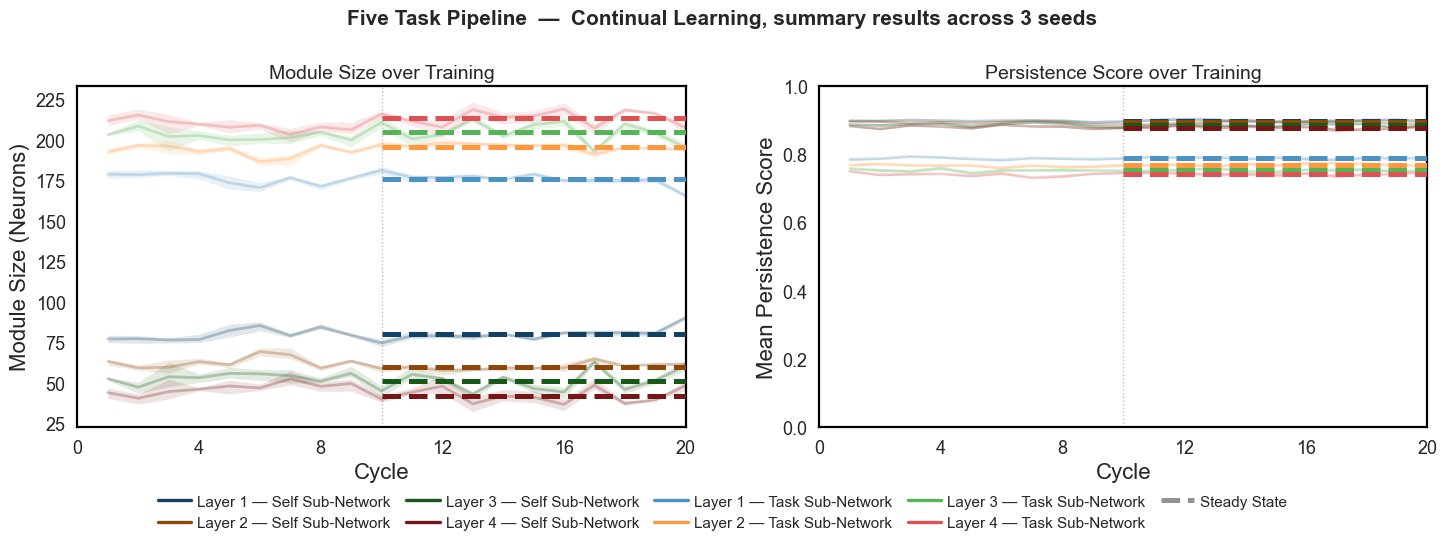

  -> Five Task Pipeline | 3 seeds | 20 cycles | conv @ cycle 10

[LOADING] Four Task Pipeline  (families: ['quadA'])


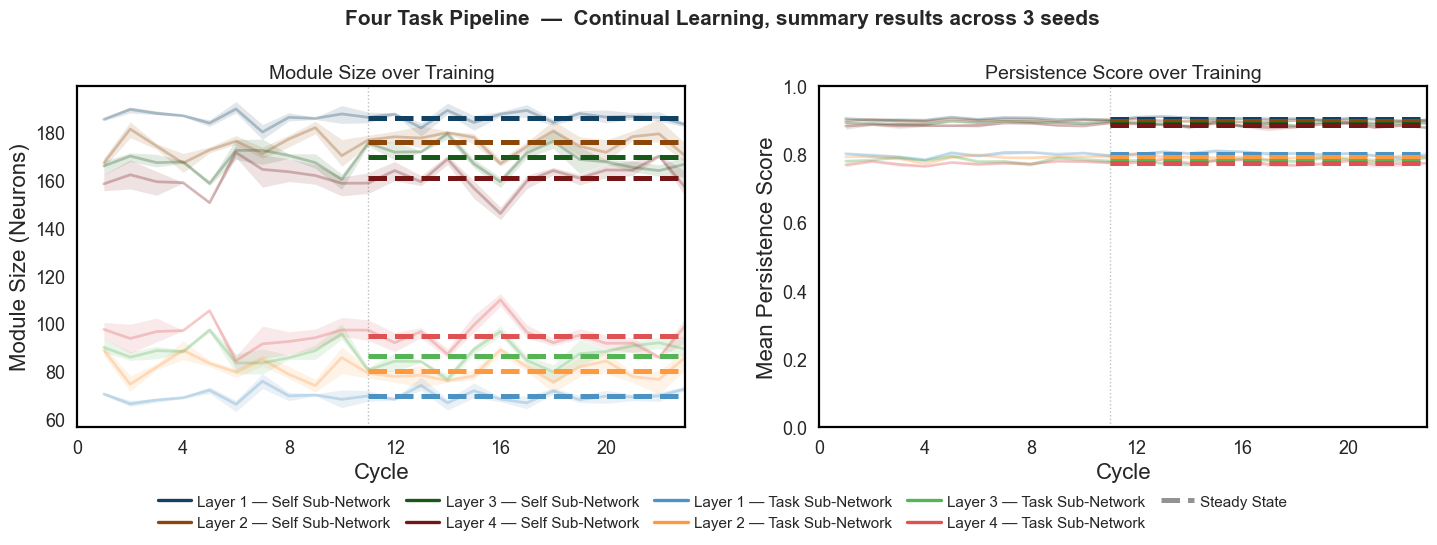

  -> Four Task Pipeline | 3 seeds | 23 cycles | conv @ cycle 11

[LOADING] Three Task Pipeline A  (families: ['triA'])


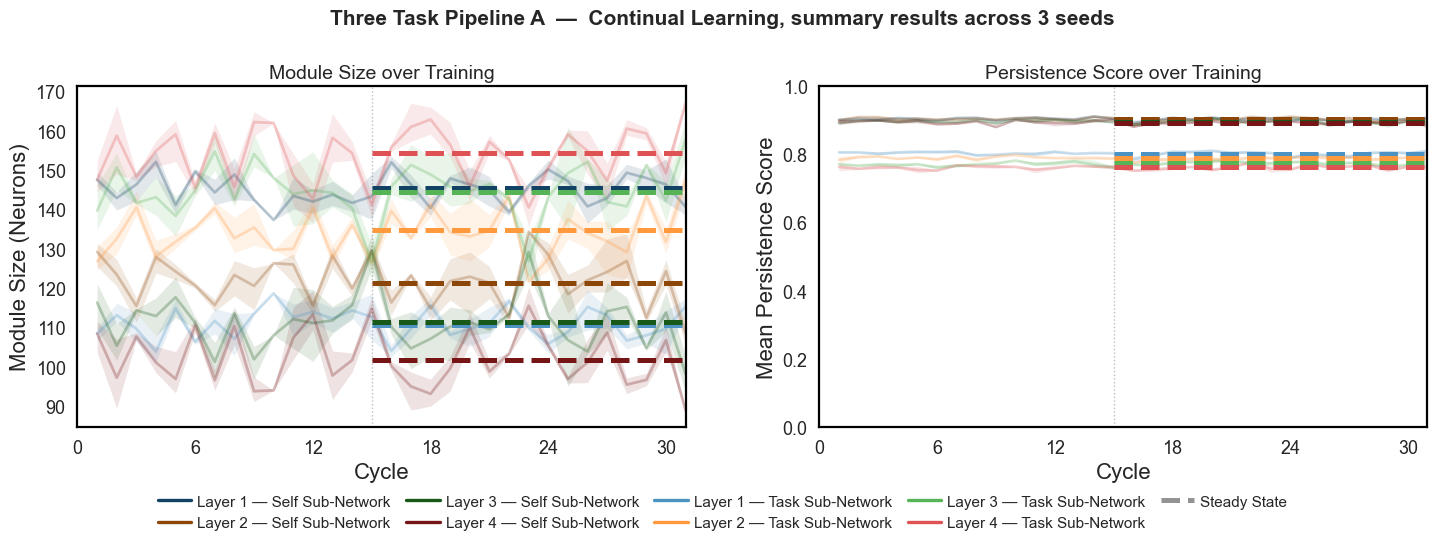

  -> Three Task Pipeline A | 3 seeds | 31 cycles | conv @ cycle 15

[LOADING] Three Task Pipeline B  (families: ['triC'])


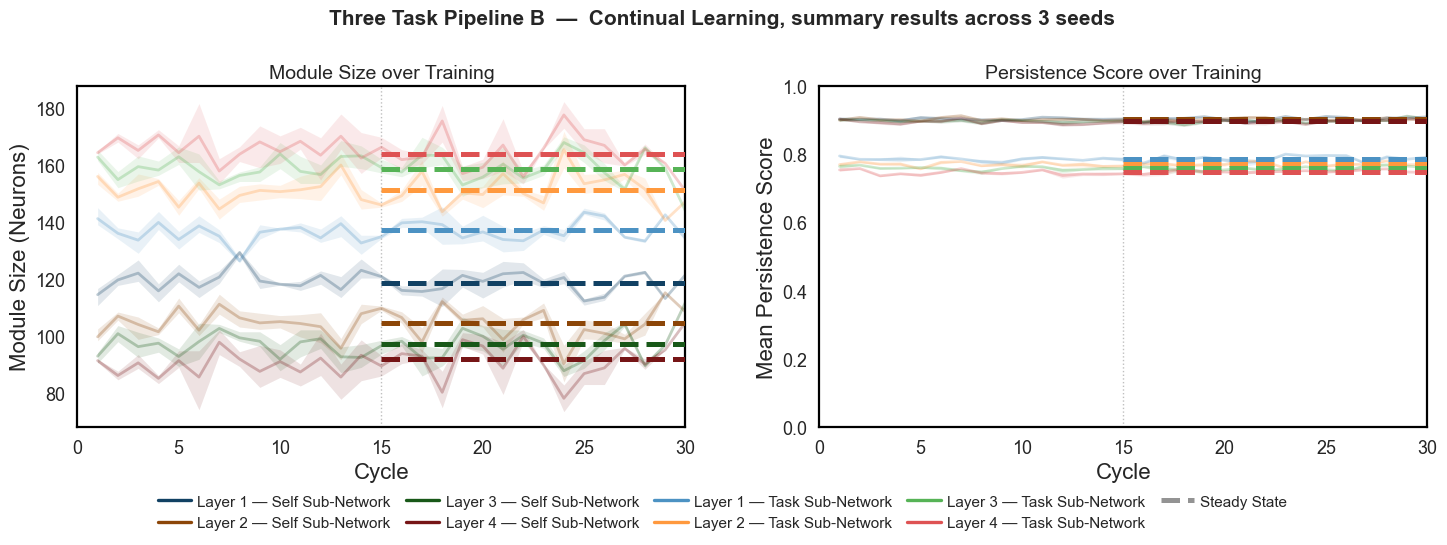

  -> Three Task Pipeline B | 3 seeds | 30 cycles | conv @ cycle 15

[DONE] All figures generated.


In [12]:
#!/usr/bin/env python3
"""
CW Module Explorer — PAPER-READY PLOTS (4 Figures, one per family group)
=========================================================================
Generates 4 side-by-side figures (module size | persistence) for:
  - Five Task Pipeline   (pentaA)
  - Four Task Pipeline   (quadA)
  - Three Task Pipeline A (triA)
  - Three Task Pipeline B (triC)

Each figure:
  - Suptitle above both panels
  - Left: Module Size vs Cycle  |  Right: Persistence Score vs Cycle
  - Light line + IQR shading for full timeline
  - Dark dashed horizontal line = mean of post-convergence window
  - Legend in two rows below both panels (repeated on every figure)
"""

from __future__ import annotations
import os, re, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from pandas.errors import EmptyDataError
from matplotlib.ticker import MaxNLocator
from matplotlib.lines import Line2D

# ============================================================
# CONFIG
# ============================================================

RUNS_ANALYSIS_ROOT = "/Users/adi/Desktop/Runs_Analysis"

# (display_name, [family_dirs], convergence_cycle)
FIGURE_SPECS = [
    ("Five Task Pipeline",    ["pentaA"],  10),
    ("Four Task Pipeline",    ["quadA"],   11),
    ("Three Task Pipeline A", ["triA"],    15),
    ("Three Task Pipeline B", ["triC"],    15),
]

MODULES_TO_PLOT  = ["self", "task"]
LAYERS_TO_PLOT   = None        # None = auto-detect from data
Q_LOW, Q_HIGH    = 0.25, 0.75
N_CYCLES_PLANNED = None        # None = use all

FIGSIZE          = (15, 5.5)
LEGEND_ROWS      = 2

AXIS_LABEL_FONTSIZE  = 16
TICK_LABEL_FONTSIZE  = 13
PANEL_TITLE_FONTSIZE = 14
SUPTITLE_FONTSIZE    = 15
LEGEND_FONTSIZE      = 11

# ============================================================
# CONFIG
# ============================================================

LW_LIGHT         = 2.0
ALPHA_LINE       = 0.28   # was 0.50; fade the full timeline more
ALPHA_BAND       = 0.12
LW_DASH          = 3.6
ALPHA_DASH       = 1.00
DASH_DARKEN      = 0.00   # was 0.32; keep dashed line same color as main line

AXIS_SPINE_LW    = 1.6
AXIS_SPINE_COLOR = "black"
TICK_WIDTH, TICK_LENGTH = 1.4, 5
N_XTICKS         = 6

mpl.rcParams["font.family"]     = "Arial"
mpl.rcParams["font.sans-serif"] = ["Arial"]
mpl.rcParams["axes.grid"]       = False
sns.set_theme(style="white")


# ============================================================
# DISCOVERY
# ============================================================

def _find_phase_csvs(root, families):
    root = os.path.expanduser(os.path.expandvars(root))
    ff   = [f.lower() for f in families]
    patterns = [
        os.path.join(root, "*", "*", "checkpoints", "accepted",
                     "_module_explorer_cache", "phase_summary.csv"),
        os.path.join(root, "accepted", "_module_explorer_cache", "phase_summary.csv"),
        os.path.join(root, "*", "accepted", "_module_explorer_cache", "phase_summary.csv"),
        os.path.join(root, "*", "*", "accepted", "_module_explorer_cache", "phase_summary.csv"),
    ]
    found = []
    for pat in patterns:
        found.extend(glob.glob(pat))
    found = sorted(set(found))
    root_parts = os.path.normpath(root).split(os.sep)
    out = []
    for p in found:
        parts = os.path.normpath(p).split(os.sep)
        if len(parts) > len(root_parts) and parts[len(root_parts)].lower() in ff:
            out.append(p)
    return out


def _extract_run_name(p, df):
    if "family_name" in df.columns and "rep_name" in df.columns:
        return f"{df['family_name'].iloc[0]}/{df['rep_name'].iloc[0]}"
    parts = os.path.normpath(p).split(os.sep)
    if "_module_explorer_cache" in parts:
        idx = parts.index("_module_explorer_cache")
        if idx >= 2 and parts[idx-1] == "accepted":
            return parts[idx-2]
        if idx >= 1:
            return parts[idx-1]
    return os.path.basename(os.path.dirname(os.path.dirname(p)))


# ============================================================
# HELPERS
# ============================================================

def _safe_read(p):
    if not os.path.exists(p) or os.path.getsize(p) < 5:
        return None, "missing/empty"
    try:
        df = pd.read_csv(p)
    except (EmptyDataError, Exception) as e:
        return None, str(e)
    if df is None or len(df) == 0:
        return None, "no rows"
    for c in ["behavior", "layer_idx", "cluster_rank"]:
        if c not in df.columns:
            return None, f"missing col: {c}"
    return df, None


def _ensure_cycle_num(df):
    if "cycle_num" in df.columns:
        df["cycle_num"] = pd.to_numeric(df["cycle_num"], errors="coerce").fillna(-1).astype(int)
        return df
    if "cycle_id" in df.columns:
        df["cycle_num"] = df["cycle_id"].apply(
            lambda x: int(re.search(r"(\d+)", str(x)).group(1))
            if re.search(r"(\d+)", str(x)) else -1
        ).astype(int)
        return df
    raise RuntimeError("Cannot determine cycle_num")


def _nanq(x, q):
    a = np.asarray(x, dtype=float); a = a[np.isfinite(a)]
    return float(np.quantile(a, q)) if a.size else np.nan

def _nfin(x):
    return int(np.sum(np.isfinite(np.asarray(x, dtype=float))))


# ============================================================
# DATA LOADING
# ============================================================

def _load_family_data(root, families):
    csvs = _find_phase_csvs(root, families)
    if not csvs:
        return None, f"No CSVs found for {families}"

    dfs = []
    for p in csvs:
        df, reason = _safe_read(p)
        if df is None:
            print(f"  [skip] {p}: {reason}"); continue
        df = df.copy()
        df["run_name"] = _extract_run_name(p, df)
        try:
            df = _ensure_cycle_num(df)
        except Exception as e:
            print(f"  [skip] {p}: {e}"); continue
        dfs.append(df)

    if not dfs:
        return None, "No valid CSVs"

    df_all = pd.concat(dfs, ignore_index=True)
    df_all["behavior"] = df_all["behavior"].astype(str).str.strip().str.lower()
    for c in ["layer_idx", "cluster_rank"]:
        df_all[c] = pd.to_numeric(df_all[c], errors="coerce").fillna(-1).astype(int)

    score_col = next(
        (c for c in ["mean_persistence_score", "mean_self_score", "mean_persistence"]
         if c in df_all.columns), None
    )
    if score_col is None:
        return None, "Missing score column"

    df_all[score_col]              = pd.to_numeric(df_all[score_col], errors="coerce")
    df_all["cluster_size_neurons"] = pd.to_numeric(
        df_all.get("cluster_size_neurons", 0), errors="coerce").fillna(0)

    # Module-level df
    group_keys = ["run_name", "behavior", "cycle_num", "layer_idx"]

    df_self = df_all[df_all["cluster_rank"] == 1].copy()
    df_self["module"] = "self"

    df_other       = df_all[df_all["cluster_rank"] >= 2].copy()
    df_other["_w"] = df_other["cluster_size_neurons"] * df_other[score_col]
    task_agg = df_other.groupby(group_keys, as_index=False).agg(
        _sz=("cluster_size_neurons","sum"), _ws=("_w","sum")
    )
    task_agg["module"]               = "task"
    task_agg[score_col]              = task_agg["_ws"] / task_agg["_sz"].replace(0, np.nan)
    task_agg["cluster_size_neurons"] = task_agg["_sz"]

    if "n_alive_units" in df_self.columns:
        alive = df_self[group_keys + ["n_alive_units","cluster_size_neurons"]].copy()
        alive = alive.rename(columns={"cluster_size_neurons":"_ss"})
        alive["n_alive_units"] = pd.to_numeric(alive["n_alive_units"], errors="coerce")
        alive["_ss"]           = pd.to_numeric(alive["_ss"], errors="coerce")
        task_agg = task_agg.merge(alive, on=group_keys, how="left")
        task_agg["cluster_size_neurons"] = (task_agg["n_alive_units"] - task_agg["_ss"]).clip(lower=0)

    dfm = pd.concat([
        df_self[group_keys + ["module","cluster_size_neurons",score_col]],
        task_agg[group_keys + ["module","cluster_size_neurons",score_col]],
    ], ignore_index=True)
    dfm["module"] = dfm["module"].str.strip().str.lower()
    dfm = dfm[dfm["module"].isin(["self","task"])].copy()
    dfm = dfm[dfm["cycle_num"] >= 0].copy()

    if N_CYCLES_PLANNED is not None:
        dfm = dfm[dfm["cycle_num"] < N_CYCLES_PLANNED].copy()

    # Per-run behavior count → completeness check per run
    run_nbeh = dfm.groupby("run_name")["behavior"].nunique().rename("run_nbeh").reset_index()
    dfm      = dfm.merge(run_nbeh, on="run_name", how="left")
    grp_beh  = (
        dfm.groupby(["run_name","cycle_num","layer_idx","module"])["behavior"]
        .nunique().reset_index().rename(columns={"behavior":"obs_nbeh"})
    )
    grp_beh  = grp_beh.merge(run_nbeh, on="run_name", how="left")
    complete = grp_beh[grp_beh["obs_nbeh"] == grp_beh["run_nbeh"]][
        ["run_name","cycle_num","layer_idx","module"]
    ]
    dfm = dfm.merge(complete, on=["run_name","cycle_num","layer_idx","module"], how="inner").copy()

    if len(dfm) == 0:
        return None, "All cycles dropped as incomplete"

    # Average behaviors within each cycle → one point per (run, cycle, layer, module)
    cycle_agg = dfm.groupby(["run_name","cycle_num","layer_idx","module"], as_index=False).agg(
        **{score_col: (score_col, "mean"),
           "cluster_size_neurons": ("cluster_size_neurons", "mean")}
    )
    cycle_agg["step_abs"] = cycle_agg["cycle_num"]

    return {
        "dfm":       cycle_agg,
        "score_col": score_col,
        "n_seeds":   int(cycle_agg["run_name"].nunique()),
        "max_cycle": int(cycle_agg["step_abs"].max()),
    }, None


# ============================================================
# COLORS
# ============================================================

_BASE = sns.color_palette("tab10", n_colors=10)

def _blend(c, o, t):
    return tuple(np.clip((1-t)*np.array(c) + t*np.array(o), 0, 1))

def _darken(c, t=0.35):  return _blend(c, (0,0,0), t)
def _lighten(c, t=0.35): return _blend(c, (1,1,1), t)

def _color(module, layer_i):
    base = _BASE[layer_i % 10]
    return _darken(base, t=0.45) if str(module)=="self" else _lighten(base, t=0.20)

def _layer_label(L):   return f"Layer {int(L)+1}"
def _mod_label(m):
    return "Self Sub-Network" if str(m).lower()=="self" else "Task Sub-Network"
def _legend_label(L,m): return f"{_layer_label(L)} — {_mod_label(m)}"


# ============================================================
# AGGREGATION
# ============================================================

def _agg(dfm, col):
    return dfm.groupby(["step_abs","layer_idx","module"])[col].agg(
        mean  ="mean",
        qlow  =lambda x: _nanq(x, Q_LOW),
        qhigh =lambda x: _nanq(x, Q_HIGH),
        n     =_nfin,
    ).reset_index()


def _dense(df_agg, layer_idx, module, which, max_step):
    sub  = df_agg[(df_agg["layer_idx"]==layer_idx) & (df_agg["module"]==module)]
    sub  = sub[["step_abs",which]].sort_values("step_abs")
    x    = np.arange(max_step+1, dtype=int)
    y    = np.full(max_step+1, np.nan, dtype=float)
    idx  = sub["step_abs"].to_numpy(dtype=int)
    vals = sub[which].to_numpy(dtype=float)
    m    = (idx >= 0) & (idx < len(y))
    y[idx[m]] = vals[m]
    return x, y


# ============================================================
# DRAWING
# ============================================================

def _format_ax(ax, max_step):
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_linewidth(AXIS_SPINE_LW)
        spine.set_color(AXIS_SPINE_COLOR)
    ax.tick_params(axis="both", which="major", labelsize=TICK_LABEL_FONTSIZE,
                   width=TICK_WIDTH, length=TICK_LENGTH, color=AXIS_SPINE_COLOR)
    ax.margins(x=0)
    ax.set_xlim(0, max_step)
    ax.xaxis.set_major_locator(MaxNLocator(N_XTICKS, integer=True))
    ax.set_xlabel("Cycle", fontsize=AXIS_LABEL_FONTSIZE)


def _draw_panel(ax, df_agg, col, ylabel, layers, max_step, conv_cycle):
    for i, L in enumerate(layers):
        for module in MODULES_TO_PLOT:
            module = str(module).strip().lower()
            c      = _color(module, i)
            c_dash = c

            x, y_mean = _dense(df_agg, L, module, "mean",  max_step)
            _, y_lo   = _dense(df_agg, L, module, "qlow",  max_step)
            _, y_hi   = _dense(df_agg, L, module, "qhigh", max_step)

            fin = np.isfinite(y_mean)
            if not np.any(fin):
                continue

            # IQR shading
            m_band = fin & np.isfinite(y_lo) & np.isfinite(y_hi)
            if np.any(m_band):
                ax.fill_between(x[m_band], y_lo[m_band], y_hi[m_band],
                                color=c, alpha=ALPHA_BAND, linewidth=0, zorder=1)

            # Light main line (full range)
            ax.plot(x[fin], y_mean[fin], color=c,
                    alpha=ALPHA_LINE, linewidth=LW_LIGHT, zorder=2)

            # Dashed horizontal = mean of post-convergence window
            post = fin & (x >= conv_cycle)
            if np.any(post):
                avg = float(np.nanmean(y_mean[post]))
                if np.isfinite(avg):
                    ax.plot([conv_cycle, max_step], [avg, avg],
                            color=c_dash, linewidth=LW_DASH,
                            linestyle="--", alpha=ALPHA_DASH, zorder=4)

    # Convergence onset marker
    ax.axvline(conv_cycle, color="grey", linewidth=1.0, linestyle=":", alpha=0.50, zorder=0)
    ax.set_ylabel(ylabel, fontsize=AXIS_LABEL_FONTSIZE)
    _format_ax(ax, max_step)


def _build_legend_handles(layers):
    handles, labels = [], []
    for module in MODULES_TO_PLOT:
        for i, L in enumerate(layers):
            c = _color(module, i)
            handles.append(Line2D([0],[0], color=c, linewidth=2.4, solid_capstyle="round"))
            labels.append(_legend_label(L, module))
    handles.append(Line2D([0],[0], color="grey", linewidth=LW_DASH, linestyle="--", alpha=0.85))
    labels.append("Steady State")
    return handles, labels


def _make_figure(display_name, data, conv_cycle):
    dfm       = data["dfm"]
    score_col = data["score_col"]
    n_seeds   = data["n_seeds"]
    max_cycle = data["max_cycle"]

    layers = sorted(dfm["layer_idx"].unique().tolist()) if LAYERS_TO_PLOT is None else list(LAYERS_TO_PLOT)

    df_size = _agg(dfm, "cluster_size_neurons")
    df_pers = _agg(dfm, score_col)

    fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)
    fig.subplots_adjust(left=0.07, right=0.97, top=0.83, bottom=0.21, wspace=0.22)

    seed_str = f"{n_seeds} seed{'s' if n_seeds != 1 else ''}"
    fig.suptitle(
        f"{display_name}  —  Continual Learning, summary results across {seed_str}",
        fontsize=SUPTITLE_FONTSIZE, fontweight="bold", y=0.97,
    )

    _draw_panel(axes[0], df_size, "cluster_size_neurons",
                "Module Size (Neurons)", layers, max_cycle, conv_cycle)
    axes[0].set_title("Module Size over Training", fontsize=PANEL_TITLE_FONTSIZE, pad=6)

    _draw_panel(axes[1], df_pers, score_col,
                "Mean Persistence Score", layers, max_cycle, conv_cycle)
    axes[1].set_title("Persistence Score over Training", fontsize=PANEL_TITLE_FONTSIZE, pad=6)
    axes[1].set_ylim(0, 1)

    handles, labels = _build_legend_handles(layers)
    n_per_row = int(np.ceil(len(handles) / LEGEND_ROWS))
    fig.legend(
        handles, labels,
        loc="lower center", bbox_to_anchor=(0.5, 0.0),
        ncol=n_per_row, fontsize=LEGEND_FONTSIZE, frameon=False,
        handlelength=2.2, handletextpad=0.4, columnspacing=1.0, borderpad=0.3,
    )

    plt.show()
    print(f"  -> {display_name} | {n_seeds} seeds | {max_cycle} cycles | conv @ cycle {conv_cycle}")


# ============================================================
# MAIN
# ============================================================

for display_name, families, conv_cycle in FIGURE_SPECS:
    print(f"\n[LOADING] {display_name}  (families: {families})")
    data, err = _load_family_data(RUNS_ANALYSIS_ROOT, families)
    if data is None:
        print(f"  [SKIP] {err}")
        continue
    _make_figure(display_name, data, conv_cycle)

print("\n[DONE] All figures generated.")

[INFO] Found 12 CSV(s)
[INFO] Loaded 12, skipped 0
[INFO] Layers : [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
[INFO] Groups present : ['3 Tasks', '4 Tasks', '5 Tasks']
  3 Tasks: 6 rep(s) — ['triA/PostVal_triA_2026-04-15_10-41-38', 'triA/PostVal_triA_rep1_2026-04-09_21-50-56', 'triA/PostVal_triA_rep2_2026-04-09_21-52-47', 'triC/PostVal_triC_2026-04-10_10-27-53', 'triC/PostVal_triC_rep1_2026-04-15_10-42-08', 'triC/PostVal_triC_rep2_2026-04-15_10-42-17']
  4 Tasks: 3 rep(s) — ['quadA/PostVal_quadA_2026-04-09_21-54-52', 'quadA/PostVal_quadA_rep1_2026-04-15_10-42-25', 'quadA/PostVal_quadA_rep2_2026-04-15_10-42-35']
  5 Tasks: 3 rep(s) — ['pentaA/PostVal_pentaA_2026-04-10_10-30-05', 'pentaA/PostVal_pentaA_rep1_2026-04-15_10-44-19', 'pentaA/PostVal_pentaA_rep2_2026-04-15_10-44-10']

[INFO] Summary rows: 96

1. Module size by layer


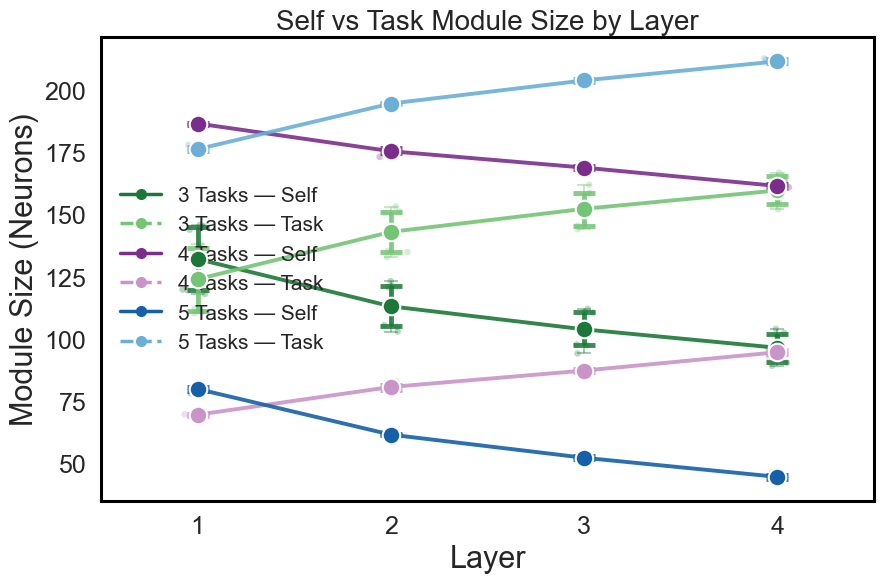


2. Persistence by layer (full range 0–1)


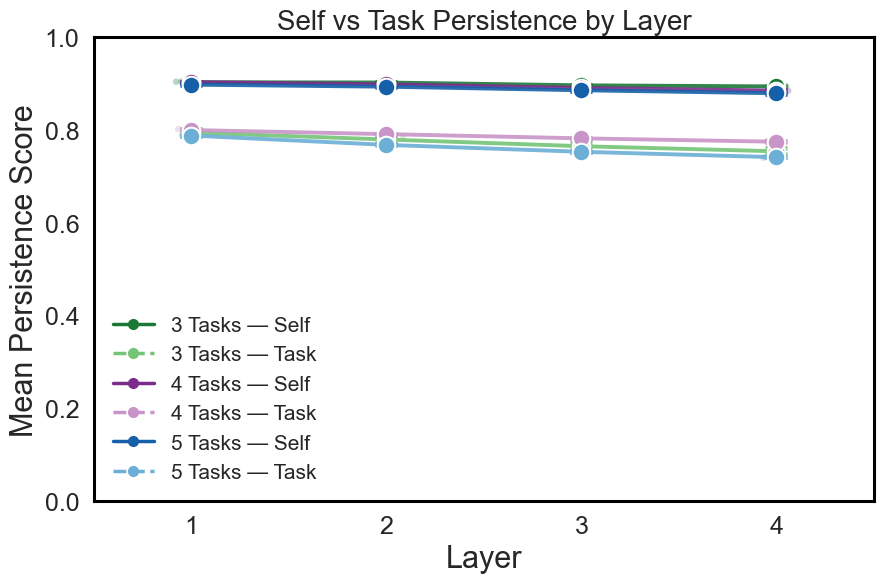


3. Persistence by layer (zoomed 0.65–1.0)


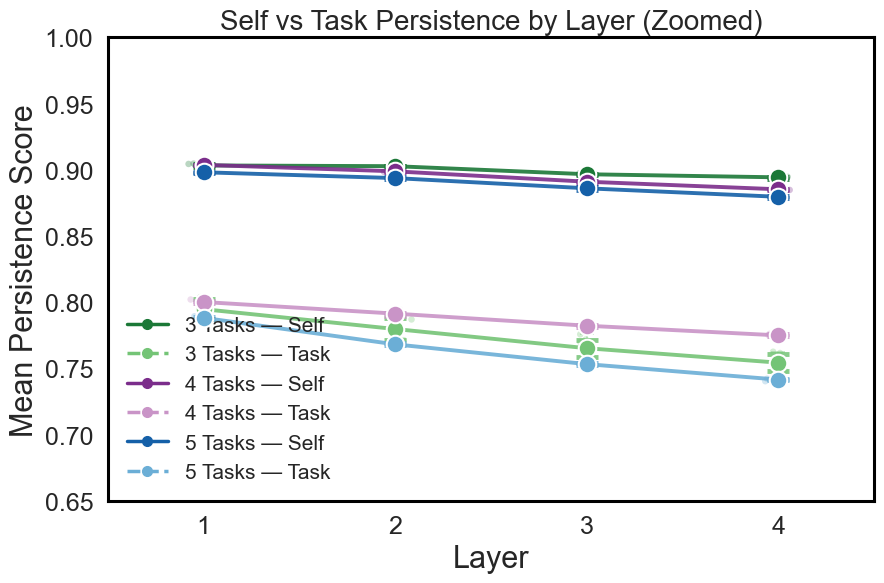


[DONE] Layer-wise comparison plots generated.


In [4]:
#!/usr/bin/env python3
"""
CW Module Explorer — LAYER-WISE COMPARISON (3 vs 4 vs 5 Tasks)
================================================================
Loads phase_summary.csv caches from the multi-family compute block and produces
layer-wise plots with one set of lines per task-count group:

  • triA + triC  →  "3 Tasks"   (green palette)
  • quadA        →  "4 Tasks"   (orange/purple palette)
  • pentaA       →  "5 Tasks"   (blue palette)

Each group shows self (dark) and task (light) sub-network lines.
Groups with no data are silently skipped.

Plots produced:
  1. Module size (neurons) vs layer
  2. Persistence score vs layer  [full range 0–1]
  3. Persistence score vs layer  [zoomed to data range]
"""

from __future__ import annotations

import os
import glob
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from pandas.errors import EmptyDataError
from matplotlib.lines import Line2D

# ============================================================
# ========================= CONFIG ===========================
# ============================================================

RUNS_ANALYSIS_ROOT = "/Users/adi/Desktop/Runs_Analysis"

# Map each group label → list of family folder names that belong to it.
# Families not listed here are ignored.
FAMILY_GROUPS = {
    "3 Tasks":  ["triA", "triC"],
    "4 Tasks":  ["quadA"],
    "5 Tasks":  ["pentaA"],
}

# Colors: for each group, (self_color, task_color)
GROUP_COLORS = {
    "3 Tasks": ("#1B7837", "#74C476"),    # dark green / light green
    "4 Tasks": ("#7B2D8B", "#C994C7"),    # dark purple / light purple
    "5 Tasks": ("#1560A8", "#6BAED6"),    # dark blue / light blue
}

MODULES_TO_PLOT = ["self", "task"]

Q_LOW  = 0.25
Q_HIGH = 0.75

FIGSIZE = (9, 6)

AXIS_LABEL_FONTSIZE = 22
TICK_LABEL_FONTSIZE = 18
TITLE_FONTSIZE      = 20
LEGEND_FONTSIZE     = 15

MARKER_SIZE_MEAN = 160
MARKER_SIZE_RUN  = 22

LINEWIDTH_CONNECT = 2.8
LINEWIDTH_IQR     = 3.5
LINEWIDTH_RANGE   = 1.4
CAP_SIZE_IQR      = 8
CAP_SIZE_RANGE    = 5

AXIS_SPINE_LINEWIDTH = 2.2
AXIS_SPINE_COLOR     = "black"
TICK_WIDTH  = 2.0
TICK_LENGTH = 7

mpl.rcParams["font.family"]     = "Arial"
mpl.rcParams["font.sans-serif"] = ["Arial"]
sns.set_theme(style="white")
mpl.rcParams["axes.grid"] = False


# ============================================================
# ======================== DISCOVERY =========================
# ============================================================

def _find_phase_csvs(root: str):
    """
    Find all phase_summary.csv files under RUNS_ANALYSIS_ROOT.
    Covers new structure: <root>/<family>/<rep>/checkpoints/accepted/_module_explorer_cache/
    and legacy structures.
    """
    root = os.path.expanduser(os.path.expandvars(root))
    patterns = [
        os.path.join(root, "*", "*", "checkpoints", "accepted",
                     "_module_explorer_cache", "phase_summary.csv"),
        os.path.join(root, "accepted", "_module_explorer_cache", "phase_summary.csv"),
        os.path.join(root, "*", "accepted", "_module_explorer_cache", "phase_summary.csv"),
        os.path.join(root, "*", "*", "accepted", "_module_explorer_cache", "phase_summary.csv"),
        os.path.join(root, "_module_explorer_cache", "phase_summary.csv"),
    ]
    found = []
    for pat in patterns:
        found.extend(glob.glob(pat))
    return sorted(set(found))


def _family_name_from_csv(csv_path: str, df: pd.DataFrame) -> str:
    """Return the family name, preferring the column written by the compute block."""
    if "family_name" in df.columns:
        return str(df["family_name"].iloc[0]).strip()
    # Fall back: immediate child of RUNS_ANALYSIS_ROOT
    parts     = os.path.normpath(csv_path).split(os.sep)
    root_parts = os.path.normpath(RUNS_ANALYSIS_ROOT).split(os.sep)
    if len(parts) > len(root_parts):
        return parts[len(root_parts)]
    return "unknown"


def _run_name_from_csv(csv_path: str, df: pd.DataFrame) -> str:
    if "family_name" in df.columns and "rep_name" in df.columns:
        return f"{df['family_name'].iloc[0]}/{df['rep_name'].iloc[0]}"
    parts = os.path.normpath(csv_path).split(os.sep)
    if "_module_explorer_cache" in parts:
        idx = parts.index("_module_explorer_cache")
        if idx >= 2 and parts[idx - 1] == "accepted":
            return parts[idx - 2]
        if idx >= 1:
            return parts[idx - 1]
    return os.path.basename(os.path.dirname(os.path.dirname(csv_path)))


def _safe_read(csv_path):
    if not os.path.exists(csv_path) or os.path.getsize(csv_path) < 5:
        return None, "missing/empty"
    try:
        df = pd.read_csv(csv_path)
    except (EmptyDataError, Exception) as e:
        return None, str(e)
    if df is None or len(df) == 0:
        return None, "no rows"
    for c in ["behavior", "layer_idx", "cluster_rank"]:
        if c not in df.columns:
            return None, f"missing col: {c}"
    return df, None


# ============================================================
# ======================== LOAD ==============================
# ============================================================

# Build reverse map: family_name → group label
family_to_group = {}
for group_label, families in FAMILY_GROUPS.items():
    for fam in families:
        family_to_group[fam.lower()] = group_label

phase_csvs = _find_phase_csvs(RUNS_ANALYSIS_ROOT)
if not phase_csvs:
    raise FileNotFoundError(f"No phase_summary.csv found under: {RUNS_ANALYSIS_ROOT}")

print(f"[INFO] Found {len(phase_csvs)} CSV(s)")

dfs, skipped = [], []
for csv_path in phase_csvs:
    df, reason = _safe_read(csv_path)
    if df is None:
        skipped.append((csv_path, reason))
        continue
    df = df.copy()
    fam  = _family_name_from_csv(csv_path, df)
    grp  = family_to_group.get(fam.lower())
    if grp is None:
        print(f"  [ignore] {fam} not in any FAMILY_GROUPS — skipping {csv_path}")
        continue
    df["family_name"] = fam
    df["group"]       = grp
    df["run_name"]    = _run_name_from_csv(csv_path, df)
    dfs.append(df)

print(f"[INFO] Loaded {len(dfs)}, skipped {len(skipped)}")
if skipped:
    for p, why in skipped: print(f"  SKIP {p}: {why}")
if not dfs:
    raise RuntimeError("No valid data loaded.")

df_all = pd.concat(dfs, ignore_index=True)

# ---- dtype fixes ----
SCORE_COL = None
for c in ["mean_persistence_score", "mean_self_score", "mean_persistence"]:
    if c in df_all.columns:
        SCORE_COL = c
        break
if SCORE_COL is None:
    raise KeyError("Missing persistence score column")

df_all[SCORE_COL]              = pd.to_numeric(df_all[SCORE_COL], errors="coerce")
df_all["cluster_size_neurons"] = pd.to_numeric(
    df_all.get("cluster_size_neurons", 0), errors="coerce").fillna(0)
df_all["layer_idx"]    = pd.to_numeric(df_all["layer_idx"],    errors="coerce").fillna(-1).astype(int)
df_all["cluster_rank"] = pd.to_numeric(df_all["cluster_rank"], errors="coerce").fillna(-1).astype(int)

# Tag module
df_all["module"] = "other"
df_all.loc[df_all["cluster_rank"] == 1,  "module"] = "self"
df_all.loc[df_all["cluster_rank"] >= 2,  "module"] = "task"
df_all = df_all[df_all["module"].isin(["self", "task"])].copy()

layers_present = sorted([L for L in df_all["layer_idx"].unique() if L >= 0])
if not layers_present:
    raise RuntimeError("No valid layers")

print(f"[INFO] Layers : {[L+1 for L in layers_present]}")
print(f"[INFO] Groups present : {sorted(df_all['group'].unique().tolist())}")
for grp in sorted(df_all["group"].unique()):
    reps = sorted(df_all.loc[df_all["group"] == grp, "run_name"].unique().tolist())
    print(f"  {grp}: {len(reps)} rep(s) — {reps}")


# ============================================================
# ======= BUILD PER-GROUP, PER-LAYER SUMMARY =================
# ============================================================
#
# Pipeline:
#   Step 1: per (run_name, layer_idx, module) → mean over all checkpoints in that rep
#   Step 2: per (group, layer_idx, module)    → mean/IQR over reps
#
# This gives equal weight to each rep regardless of checkpoint count.

group_keys_rep = ["group", "run_name", "layer_idx"]

# --- SELF ---
df_self = df_all[df_all["module"] == "self"].copy()
self_per_rep = df_self.groupby(group_keys_rep, as_index=False).agg(
    mean_size  = ("cluster_size_neurons", "mean"),
    mean_score = (SCORE_COL, "mean"),
)
self_per_rep["module"] = "self"

# --- TASK: weighted-average score per checkpoint first, then average per rep ---
df_task = df_all[df_all["module"] == "task"].copy()

if "cycle_num" in df_task.columns and "behavior" in df_task.columns:
    ckpt_keys = ["group", "run_name", "layer_idx", "cycle_num", "behavior"]
elif "global_idx" in df_task.columns:
    ckpt_keys = ["group", "run_name", "layer_idx", "global_idx"]
else:
    ckpt_keys = ["group", "run_name", "layer_idx", "seq_id"]

df_task["_w"] = df_task["cluster_size_neurons"] * df_task[SCORE_COL]
task_per_ckpt = df_task.groupby(ckpt_keys, as_index=False).agg(
    size_sum = ("cluster_size_neurons", "sum"),
    w_sum    = ("_w", "sum"),
)
task_per_ckpt["ckpt_score"] = task_per_ckpt["w_sum"] / task_per_ckpt["size_sum"].replace(0, np.nan)
task_per_ckpt["ckpt_size"]  = task_per_ckpt["size_sum"]

task_per_rep = task_per_ckpt.groupby(group_keys_rep, as_index=False).agg(
    mean_size  = ("ckpt_size",  "mean"),
    mean_score = ("ckpt_score", "mean"),
)
task_per_rep["module"] = "task"

# Combine
summary = pd.concat([self_per_rep, task_per_rep], ignore_index=True)
print(f"\n[INFO] Summary rows: {len(summary)}")


# ============================================================
# =================== AXIS FORMATTING =======================
# ============================================================

def _format_axes(ax, layers):
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_linewidth(AXIS_SPINE_LINEWIDTH)
        spine.set_color(AXIS_SPINE_COLOR)
    ax.tick_params(axis="both", which="major", labelsize=TICK_LABEL_FONTSIZE,
                   width=TICK_WIDTH, length=TICK_LENGTH, color=AXIS_SPINE_COLOR)
    ax.set_xticks(layers)
    ax.set_xticklabels([str(int(L) + 1) for L in layers], fontsize=TICK_LABEL_FONTSIZE)
    ax.set_xlim(min(layers) - 0.5, max(layers) + 0.5)


# ============================================================
# =================== PLOT FUNCTION ==========================
# ============================================================

def _plot_layerwise(summary, value_col, ylabel, title, ylim=None):
    fig, ax = plt.subplots(figsize=FIGSIZE)
    rng = np.random.default_rng(42)

    legend_handles = []

    for group_label in FAMILY_GROUPS.keys():           # fixed order: 3, 4, 5 tasks
        grp_data = summary[summary["group"] == group_label]
        if len(grp_data) == 0:
            print(f"  [skip] {group_label} — no data for {value_col}")
            continue

        color_self, color_task = GROUP_COLORS[group_label]

        for module in MODULES_TO_PLOT:
            module     = str(module).lower()
            color_mean = color_self if module == "self" else color_task
            color_run  = color_mean + "88"   # add alpha-ish by making lighter via scatter alpha

            mod_data = grp_data[grp_data["module"] == module]
            if len(mod_data) == 0:
                continue

            line_x, line_y = [], []

            for L in layers_present:
                layer_data = mod_data[mod_data["layer_idx"] == L]
                vals = layer_data[value_col].dropna().to_numpy(dtype=float)
                vals = vals[np.isfinite(vals)]

                if vals.size == 0:
                    continue

                x_pos    = float(L)
                mean_val = float(np.mean(vals))
                q_lo     = float(np.quantile(vals, Q_LOW))  if vals.size > 1 else mean_val
                q_hi     = float(np.quantile(vals, Q_HIGH)) if vals.size > 1 else mean_val
                v_min    = float(np.min(vals))
                v_max    = float(np.max(vals))

                # Individual rep dots (jittered)
                jitter = rng.normal(0, 0.04, size=vals.size)
                ax.scatter(
                    np.full(vals.size, x_pos) + jitter, vals,
                    s=MARKER_SIZE_RUN, color=color_mean, alpha=0.30,
                    zorder=2, edgecolors="none",
                )

                # Range whisker (thin)
                ax.errorbar(
                    x_pos, mean_val,
                    yerr=[[mean_val - v_min], [v_max - mean_val]],
                    fmt="none", ecolor=color_mean,
                    elinewidth=LINEWIDTH_RANGE, capsize=CAP_SIZE_RANGE,
                    capthick=LINEWIDTH_RANGE, alpha=0.40, zorder=3,
                )

                # IQR whisker (thick)
                ax.errorbar(
                    x_pos, mean_val,
                    yerr=[[mean_val - q_lo], [q_hi - mean_val]],
                    fmt="none", ecolor=color_mean,
                    elinewidth=LINEWIDTH_IQR, capsize=CAP_SIZE_IQR,
                    capthick=LINEWIDTH_IQR, alpha=0.85, zorder=4,
                )

                # Mean marker
                ax.scatter(
                    [x_pos], [mean_val],
                    s=MARKER_SIZE_MEAN, color=color_mean,
                    edgecolors="white", linewidths=1.5, zorder=6, marker="o",
                )

                line_x.append(x_pos)
                line_y.append(mean_val)

            # Connecting line
            if len(line_x) > 1:
                ax.plot(line_x, line_y, color=color_mean,
                        linewidth=LINEWIDTH_CONNECT, alpha=0.90, zorder=5)

        # Legend entries: one solid + one dashed line per group
        c_s, c_t = GROUP_COLORS[group_label]
        legend_handles.append(
            Line2D([0], [0], color=c_s, linewidth=2.5,
                   marker="o", markersize=7, markerfacecolor=c_s,
                   label=f"{group_label} — Self")
        )
        legend_handles.append(
            Line2D([0], [0], color=c_t, linewidth=2.5,
                   marker="o", markersize=7, markerfacecolor=c_t,
                   linestyle="--",
                   label=f"{group_label} — Task")
        )

    ax.set_xlabel("Layer", fontsize=AXIS_LABEL_FONTSIZE)
    ax.set_ylabel(ylabel, fontsize=AXIS_LABEL_FONTSIZE)
    ax.set_title(title, fontsize=TITLE_FONTSIZE)
    ax.title.set_y(1.03)
    if ylim is not None:
        ax.set_ylim(*ylim)
    _format_axes(ax, layers_present)

    ax.legend(handles=legend_handles, loc="best", fontsize=LEGEND_FONTSIZE,
              frameon=False, ncol=1)

    plt.tight_layout()
    plt.show()


# ============================================================
# =================== GENERATE PLOTS ========================
# ============================================================

print("\n" + "=" * 60)
print("1. Module size by layer")
print("=" * 60)
_plot_layerwise(
    summary,
    value_col = "mean_size",
    ylabel    = "Module Size (Neurons)",
    title     = "Self vs Task Module Size by Layer",
)

print("\n" + "=" * 60)
print("2. Persistence by layer (full range 0–1)")
print("=" * 60)
_plot_layerwise(
    summary,
    value_col = "mean_score",
    ylabel    = "Mean Persistence Score",
    title     = "Self vs Task Persistence by Layer",
    ylim      = (0, 1),
)

# Auto-detect zoom range
all_scores = summary["mean_score"].dropna().to_numpy(dtype=float)
all_scores = all_scores[np.isfinite(all_scores)]
zoom_lo    = max(0.0, round(np.floor(float(np.min(all_scores)) * 20) / 20 - 0.05, 2)) \
    if all_scores.size else 0.75

print(f"\n{'='*60}")
print(f"3. Persistence by layer (zoomed {zoom_lo}–1.0)")
print("=" * 60)
_plot_layerwise(
    summary,
    value_col = "mean_score",
    ylabel    = "Mean Persistence Score",
    title     = "Self vs Task Persistence by Layer (Zoomed)",
    ylim      = (zoom_lo, 1.0),
)

print("\n[DONE] Layer-wise comparison plots generated.")